# Exploratory Data Analysis

This notebook presents a comprehensive Exploratory Data Analysis (EDA) of the *Airbnb listings dataset*, containing **74,111 observations**. The primary objective of the project is to solve a **regression** task by predicting the target variable based on listing characteristics, host information, location, amenities and textual description.

Unlike the traditional EDA that focuses solely on analyzing the raw dataset, this notebook also includes **feature extraction** and **feature analysis**. Newly created features are evaluated immediately after their construction to determine thier usefulness, statistical properties and potentional contribution to the predictive model.

The hybrid approach was intentionally chosen to keep the entire data understanding and feature engineering process in a single notebook. As a result, all preprocessing decisions, feature engineering steps and modeling recommendations are documented alongside the corresponding analyses. By the end of this EDA, the project will contain a well-defined set of features together with clear guidlines for preprocessing, encoding, scaling and feature selection, significantly simplifying the implementation of the modeling pipeline. 

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sys

sns.set_style("darkgrid")
pd.set_option("display.max_columns", 100)

ROOT = Path.cwd().parent.resolve()
DATASET_PATH = ROOT / "dataset" / "Airbnb_Data.csv"

df = pd.read_csv(DATASET_PATH)

# Use Python string backend because the project relies on advanced regex features
df['description'] = df['description'].astype("string[python]")
df.head()

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,NYC,"Beautiful, sunlit brownstone 1-bedroom in the ...",2016-06-18,t,t,NaN,2012-03-26,f,2016-07-18,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,NYC,Enjoy travelling during your stay in Manhattan...,2017-08-05,t,f,100%,2017-06-19,t,2017-09-23,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,NYC,The Oasis comes complete with a full backyard ...,2017-04-30,t,t,100%,2016-10-25,t,2017-09-14,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,SF,This light-filled home-away-from-home is super...,NaN,t,t,NaN,2015-04-19,f,NaN,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,DC,"Cool, cozy, and comfortable studio located in ...",2015-05-12,t,t,100%,2015-03-01,t,2017-01-22,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


In [2]:
df.shape

(74111, 29)

In [3]:
df.dtypes

id                          int64
log_price                 float64
property_type                 str
room_type                     str
amenities                     str
accommodates                int64
bathrooms                 float64
bed_type                      str
cancellation_policy           str
cleaning_fee                 bool
city                          str
description                string
first_review                  str
host_has_profile_pic          str
host_identity_verified        str
host_response_rate            str
host_since                    str
instant_bookable              str
last_review                   str
latitude                  float64
longitude                 float64
name                          str
neighbourhood                 str
number_of_reviews           int64
review_scores_rating      float64
thumbnail_url                 str
zipcode                       str
bedrooms                  float64
beds                      float64
dtype: object

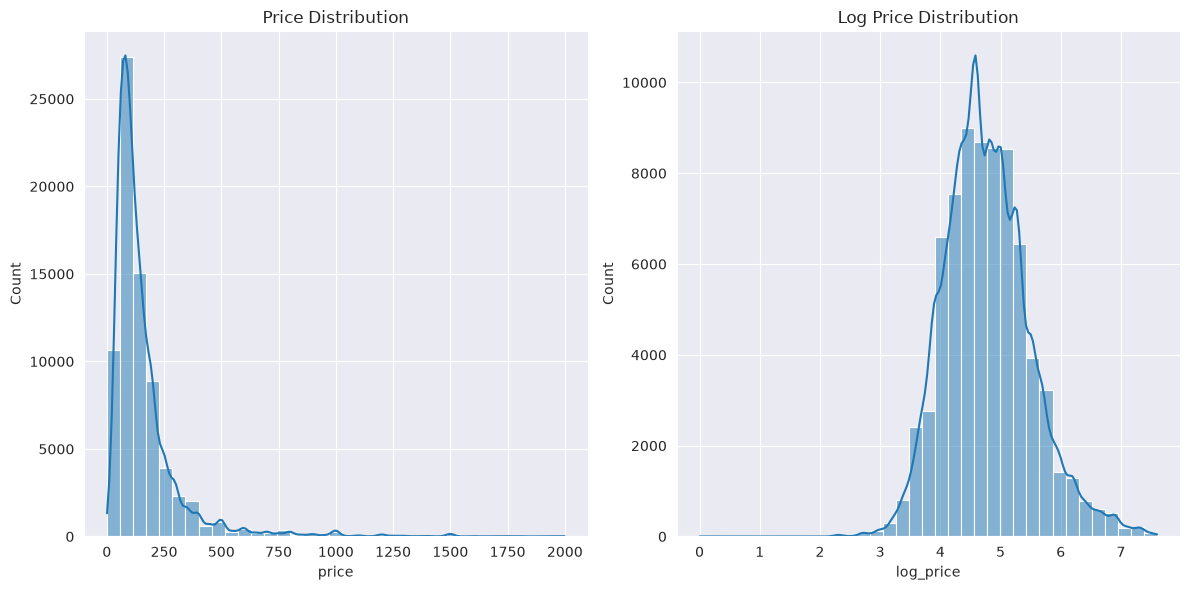

In [4]:
df['price'] = np.exp(df['log_price'])

fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(12, 6))
sns.histplot(data=df, x='price', bins=35, kde=True, ax=axes[0])
sns.histplot(data=df, x='log_price', bins=35, kde=True, ax=axes[1])

axes[0].set_title("Price Distribution")
axes[1].set_title("Log Price Distribution")

plt.tight_layout()
plt.show()

## NaN Report

In [5]:
nan_report = df.isna().mean().sort_values(ascending=False)
nan_report

host_response_rate        0.246913
review_scores_rating      0.225635
first_review              0.214057
last_review               0.213558
thumbnail_url             0.110861
neighbourhood             0.092726
zipcode                   0.013035
bathrooms                 0.002699
host_identity_verified    0.002537
host_since                0.002537
host_has_profile_pic      0.002537
beds                      0.001768
bedrooms                  0.001228
property_type             0.000000
city                      0.000000
description               0.000000
cancellation_policy       0.000000
cleaning_fee              0.000000
bed_type                  0.000000
room_type                 0.000000
amenities                 0.000000
accommodates              0.000000
log_price                 0.000000
id                        0.000000
latitude                  0.000000
instant_bookable          0.000000
name                      0.000000
longitude                 0.000000
number_of_reviews   

In [6]:
(df['last_review'].isna() == df['first_review'].isna()).mean()

np.float64(0.9995007488766849)

In [7]:
(
    (df['host_identity_verified'].isna() == df['host_since'].isna()) &
    (df['host_identity_verified'].isna() == df['host_has_profile_pic'].isna())
).mean()

np.float64(1.0)

In [8]:
df['host_response_rate'] = pd.to_numeric(
    df['host_response_rate'].str.replace("%", "", regex=False),
    errors="coerce"
)

df['host_response_rate'].describe()

count    55812.000000
mean        94.351967
std         16.341817
min          0.000000
25%        100.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: host_response_rate, dtype: float64

In [9]:
df['host_response_rate'].value_counts(normalize=True).mul(100).round(2).head(10)

host_response_rate
100.0    77.50
90.0      4.08
80.0      1.99
0.0       1.58
50.0      1.09
70.0      0.91
99.0      0.80
67.0      0.78
98.0      0.76
94.0      0.72
Name: proportion, dtype: float64

In [10]:
(df['host_response_rate'].isna() == df['host_identity_verified'].isna()).mean()

np.float64(0.7556233217740956)

In [11]:
pd.crosstab(
    df['host_response_rate'].isna(),
    df['host_identity_verified'].isna()
)

host_identity_verified,False,True
host_response_rate,,
False,55812,0
True,18111,188


In [12]:
cols = nan_report[nan_report > 0].index.tolist()

for col in cols:
    print("\n-------------------------------------")
    print(df.groupby(df[col].isna())['price'].agg(
        ['count', 'mean', 'median']
    ))


-------------------------------------
                    count        mean  median
host_response_rate                           
False               55812  154.705726   110.0
True                18299  177.649489   115.0

-------------------------------------
                      count        mean  median
review_scores_rating                           
False                 57389  147.748297   110.0
True                  16722  203.690767   120.0

-------------------------------------
              count        mean  median
first_review                           
False         58247  147.794393   110.0
True          15864  206.547151   120.0

-------------------------------------
             count        mean  median
last_review                           
False        58284  147.785207   110.0
True         15827  206.718329   120.0

-------------------------------------
               count        mean  median
thumbnail_url                           
False          65895  153.18487

In [13]:
pd.crosstab(
    df['thumbnail_url'].isna(),
    df['first_review'].isna()
)

first_review,False,True
thumbnail_url,,
False,52325,13570
True,5922,2294


### Missing Value Analysis Conclusion

During the analysis of missing values, several features with missing values were identified. The highest proportion of missing values was found in:

* `host_response_rate` (~ 24.7%)
* `review_scores_rating` (~ 22.6%)
* `first_review` (~ 21.4%)
* `last_review` (~ 21.3%)
* `thumbnail_url` (~ 11.1%)
* `neighbourhood` (~ 9.3%)

The analysis showed that missing values in the dataset are **not random** and may represent meaningful information.

For *review-related* features (`first_review`, `last_review`), missing values show a strong relationship. In particular `first_review` and `last_review` have almost identical missingness patterns (~99%), suggesting that they represent the same factor: the presence and absence of review history.

Listings without review information have different price distributions compared to listings with reviews. Therefore, missing *review-related* values should not be removed as the absence of reviews itself may be an informative feature.

A similar pattern was observed for `host_response_rate`. Since the feature was originally stored as a percentage string, it was first converted to a numeric representation, to enable statistical analysis. The feature contains the largest proportion of missing values, while the available values are highly concentrated around 100%. Since missing values may indicate the absence of host interaction history rather than poor response performance, the missingness may carry predictive information.

The *host-related features* `host_has_profile_pic`, `host_identity_verified` and `host_since` were found to have identical missingness patterns across these features. This indicates that these missing values originate from the same issue. Creating one common flag, such as **host_missing** can be a possible solution.

The `thumbnail_url` feature also showed a meaningful relationship with price. Listings without thumbnail had a different price distribution, suggesting that the absence of an image may describe a specific group of listings rather than a random missing data.

Based on the analysis, the following preprocessing strategy will be considered for the modeling stage:

* Do not remove rows containing missing values, as many missing values appear to have specific predictive meaning.
* `host_response_rate` can be filled with median value, while preserving information through a binary indicator.
* Categorical features with missing values can be filled with **Unknown** value.
* `host-related features` may share one flag for missing values: **host_missing**. `host_since` is a **DateTime** feature and considered to transfrom DateTime information into host age(`days_count`) and fill missing values with median while preserving the missing flag.
* `thumbnail_url` is considered to be transformed into a binary feature.

----

## Duplicate Inspection

In [14]:
# Exclude the unique listing identifier before duplicate inspection,
# since every listing has a unique id by definition
df_copy = df.drop(columns='id')

# Check for duplicated observations
df_copy.duplicated().sum()

np.int64(0)

### Duplicate Inspection Conclusion

The duplicate inspection was performed after excluding the `id` column, as it is a unique identifier for each listing and would prevent the detection of duplicated observations. No duplicate records were found in the dataset, indicating that each listing represents a unique observaation and no duplicate removal is required.

## Target Variable Analysis

Goals for this section:

1. Understand distribution of the target variable (`price`);
2. Identify skewness and asymmetry;
3. Detect potential outliers and extreme values;

In [15]:
df['price'].describe()

count    74111.000000
mean       160.370849
std        168.580415
min          1.000000
25%         75.000000
50%        111.000000
75%        185.000000
max       1999.000000
Name: price, dtype: float64

In [16]:
df[df['price'] == 1].T

,11632
id,17972519
log_price,0.0
property_type,Condominium
room_type,Shared room
amenities,"{TV,""Wireless Internet"",""Air conditioning"",Kit..."
accommodates,1
bathrooms,1.0
bed_type,Real Bed
cancellation_policy,strict
cleaning_fee,True


In [17]:
df[df['price'] <= 10]['city'].value_counts()

city
NYC    2
Name: count, dtype: int64

In [18]:
df[df['price'] <= 10]['room_type'].value_counts()

room_type
Entire home/apt    1
Shared room        1
Name: count, dtype: int64

In [19]:
df[df['price'] <= 6][[
    'price',
    'name',
    'room_type',
    'property_type',
    'accommodates',
    'bedrooms',
    'number_of_reviews',
    'review_scores_rating',
    'host_since'
]].T

,3898,11632
price,5.0,1.0
name,Upper West Side Studio Steps from Central Park,Esteem's Place
room_type,Entire home/apt,Shared room
property_type,Apartment,Condominium
accommodates,2,1
bedrooms,0.0,1.0
number_of_reviews,1,3
review_scores_rating,100.0,87.0
host_since,2013-08-14,2017-07-20


In [20]:
(df['log_price'] == 0).sum()

np.int64(1)

In [21]:
(df['log_price'] == 1).sum()

np.int64(0)

In [22]:
df['price'].nsmallest(20)

11632     1.0
3898      5.0
4466     10.0
6515     10.0
19806    10.0
21282    10.0
22268    10.0
23304    10.0
23917    10.0
25239    10.0
25655    10.0
26000    10.0
27021    10.0
28685    10.0
28693    10.0
37651    10.0
43269    10.0
48734    10.0
50577    10.0
52000    10.0
Name: price, dtype: float64

In [23]:
df.nsmallest(20, 'price')[[
    'city',
    'room_type',
    'property_type',
    'accommodates',
    'bedrooms',
    'number_of_reviews',
    'price'
]]

,city,room_type,property_type,accommodates,bedrooms,number_of_reviews,price
11632,NYC,Shared room,Condominium,1,1.0,3,1.0
3898,NYC,Entire home/apt,Apartment,2,0.0,1,5.0
4466,LA,Private room,Apartment,1,1.0,0,10.0
6515,Chicago,Private room,Apartment,1,1.0,78,10.0
19806,SF,Private room,Apartment,2,1.0,1,10.0
21282,Chicago,Shared room,House,2,1.0,1,10.0
22268,NYC,Private room,Apartment,2,1.0,0,10.0
23304,LA,Shared room,House,1,1.0,0,10.0
23917,NYC,Shared room,Apartment,1,1.0,2,10.0
25239,DC,Shared room,Apartment,4,1.0,41,10.0


In [24]:
df[df['price'] <= df['price'].quantile(0.01)][
    [
        'city',
        'room_type',
        'property_type',
        'accommodates',
        'bedrooms',
        'number_of_reviews',
        'price'
    ]
].sort_values('price')

,city,room_type,property_type,accommodates,bedrooms,number_of_reviews,price
11632,NYC,Shared room,Condominium,1,1.0,3,1.0
3898,NYC,Entire home/apt,Apartment,2,0.0,1,5.0
69004,SF,Entire home/apt,House,1,0.0,0,10.0
4466,LA,Private room,Apartment,1,1.0,0,10.0
57623,NYC,Private room,Apartment,1,0.0,2,10.0
...,...,...,...,...,...,...,...
4100,LA,Private room,Apartment,1,1.0,0,29.0
12056,NYC,Private room,Apartment,2,1.0,4,29.0
74030,LA,Shared room,Apartment,1,1.0,0,29.0
238,LA,Private room,House,1,1.0,4,29.0


In [25]:
df['price'].quantile([
    0.001,
    0.005,
    0.01,
    0.02,
    0.05,
    0.1
])

0.001    15.0
0.005    25.0
0.010    29.0
0.020    33.0
0.050    40.0
0.100    50.0
Name: price, dtype: float64

In [26]:
df['price'].quantile([
    0.90,
    0.95,
    0.99,
    0.995,
    0.999
])

0.900     300.0
0.950     425.0
0.990     986.8
0.995    1200.0
0.999    1650.0
Name: price, dtype: float64

In [257]:
df['price'].skew(), df['log_price'].skew()

(np.float64(4.298408387699143), np.float64(0.5146954132526466))

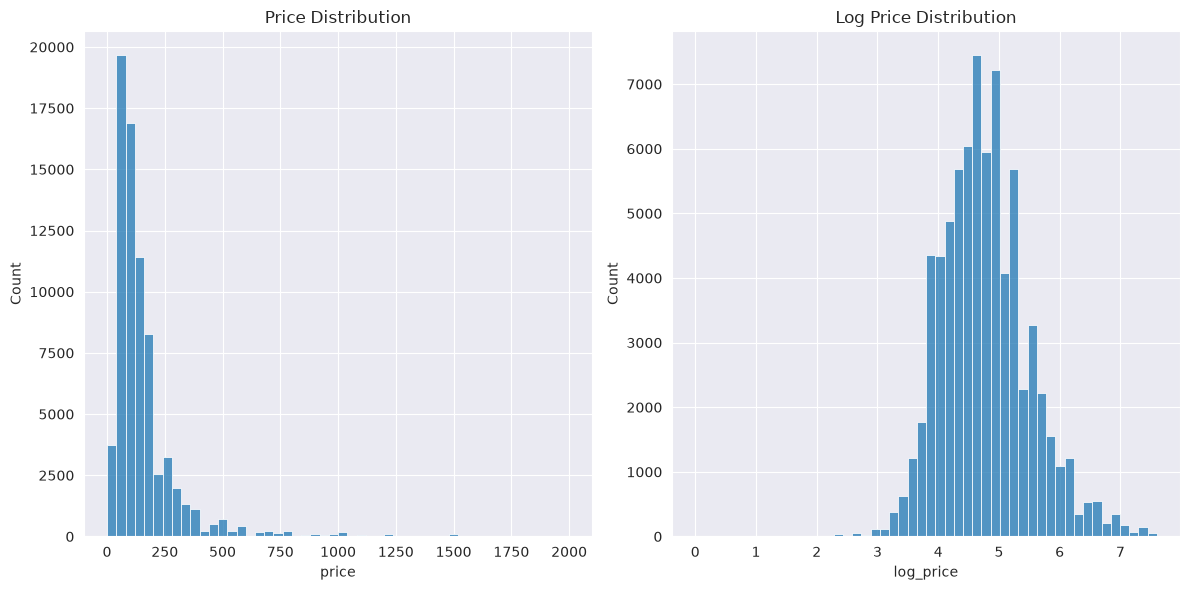

In [28]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(12, 6 ))

sns.histplot(data=df, x='price', bins=50, ax=axes[0])
sns.histplot(data=df, x='log_price', bins=50, ax=axes[1])

axes[0].set_title("Price Distribution")
axes[1].set_title("Log Price Distribution")

plt.tight_layout()
plt.show()

### Target Variable Analysis Conclusion

The target varibale `price` shows a strong right-skewed distribution with a skewness value of 4.30.

Most listings are connected in the lower price range, while a small number of expensive listings create a long right tail.

The analysis of quantiles shows that 90% of listings have a price below `$300`, while the top 1% of listings exceed approximately `$987`. These high-priced observations represent a small premium segment rather than obvious data errors.

The lower tail was also investigated. A single listing with a price of `$1` was identified. After examining its associated features, the observation appeared to be a valid but extremely low-priced listings. Since no clear data inconsistencies were found, these observations were retained.

The logarithmic transformation (`log_price`) significantly reduces the skewness from 4.30 to 0.51, resulting in a more balanced target distribution. Therefore, `log_price` will be used as a target variable for regression modeling.

## DateTime Analysis

Goals for this section:

1. Explore the temporal characteristics of date-related features;
2. Extract meaningful time-based features;
3. Analyze relationships between time-based features and targer variable;

In [29]:
date_cols = [
    'first_review',
    'host_since',
    'last_review'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

df[date_cols].dtypes

first_review    datetime64[us]
host_since      datetime64[us]
last_review     datetime64[us]
dtype: object

In [30]:
df[date_cols].describe()

,first_review,host_since,last_review
count,58247,73923,58284
mean,2016-01-14 08:11:51.013443,2014-07-21 01:55:09.849438,2017-03-14 19:27:18.789376
min,2008-11-17 00:00:00,2008-03-03 00:00:00,2009-01-21 00:00:00
25%,2015-06-28 00:00:00,2013-04-21 00:00:00,2017-01-09 00:00:00
50%,2016-05-25 00:00:00,2014-09-28 00:00:00,2017-04-28 00:00:00
75%,2017-01-02 00:00:00,2015-12-22 00:00:00,2017-09-08 00:00:00
max,2017-10-05 00:00:00,2017-10-04 00:00:00,2017-10-05 00:00:00


In [258]:
# Calculate host experience in days.
# The most recent `host_since` date in the dataset is used as reference.
# to ensure a consistent observation point for all listings.
reference_date = df['host_since'].max()

df['host_age_days'] = (reference_date - df['host_since']).dt.days
df['host_age_days'].describe()

count    73923.000000
mean      1170.920025
std        661.497132
min          0.000000
25%        652.000000
50%       1102.000000
75%       1627.000000
max       3502.000000
Name: host_age_days, dtype: float64

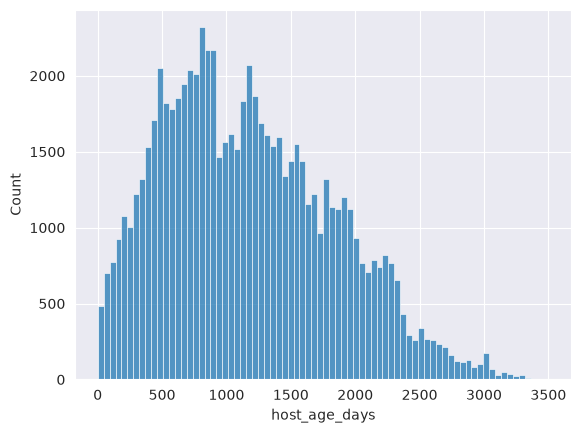

In [32]:
sns.histplot(data=df, x='host_age_days')
plt.show()

In [33]:
reference_date = df['last_review'].max()

df['days_since_last_review'] = (
    reference_date - df['last_review']
).dt.days

df['days_since_last_review'].describe()

count    58284.000000
mean       204.189366
std        231.729791
min          0.000000
25%         27.000000
50%        160.000000
75%        269.000000
max       3179.000000
Name: days_since_last_review, dtype: float64

In [34]:
df['review_history_days'] = (
    df['last_review'] - df['first_review']
).dt.days

df['review_history_days'].describe()

count    58247.000000
mean       425.461311
std        488.988636
min          0.000000
25%         52.000000
50%        264.000000
75%        623.000000
max       3106.000000
Name: review_history_days, dtype: float64

In [35]:
df['host_since_year'] = df['host_since'].dt.year
df['last_review_year'] = df['last_review'].dt.year
df['first_review_year'] = df['first_review'].dt.year

In [36]:
df[df['first_review'] < df['host_since']][[
    'host_since',
    'first_review',
    'last_review',
    'review_scores_rating',
    'price'
]]

,host_since,first_review,last_review,review_scores_rating,price
163,2013-09-25,2013-08-01,2017-09-20,88.0,90.0
950,2013-12-13,2012-05-21,2017-09-09,91.0,75.0
3828,2012-02-05,2011-12-24,2017-03-22,98.0,58.0
5401,2012-08-27,2012-07-23,2017-04-30,88.0,109.0
6736,2013-07-25,2012-10-27,2017-03-05,93.0,100.0
7634,2012-03-04,2011-07-11,2017-09-19,93.0,480.0
8097,2015-10-15,2015-07-06,2017-04-27,96.0,180.0
8888,2013-11-20,2013-05-06,2016-12-25,95.0,450.0
11237,2013-11-20,2012-04-01,2017-04-03,100.0,190.0
12765,2013-10-06,2013-05-06,2016-09-14,93.0,90.0


In [37]:
(df['first_review'] < df['host_since']).sum()

np.int64(44)

In [38]:
df['review_before_host'] = (
    df['first_review'] < df['host_since']
).astype(int)

In [39]:
datetime_features = [
    'host_age_days',
    'days_since_last_review',
    'review_history_days',
    'review_before_host'
]

df[datetime_features + ['log_price']].corr()['log_price'].sort_values()

review_before_host        0.007554
days_since_last_review    0.021550
review_history_days       0.073443
host_age_days             0.078333
log_price                 1.000000
Name: log_price, dtype: float64

In [40]:
df.groupby('host_since_year')['price'].agg(
    ['median', 'mean', 'count']
)

,median,mean,count
host_since_year,,,
2008.0,95.0,137.439560,91
2009.0,129.0,162.646132,698
2010.0,125.0,157.367497,1766
2011.0,125.0,170.343769,4887
2012.0,120.0,163.315359,8308
2013.0,120.0,162.920775,10729
2014.0,114.0,161.452009,13690
2015.0,108.0,157.326087,15594
2016.0,100.0,159.080667,13190


In [41]:
df.groupby('first_review_year')['price'].agg(
    ['median', 'mean', 'count']
)

,median,mean,count
first_review_year,,,
2008.0,36.0,36.000000,1
2009.0,120.0,129.160714,56
2010.0,124.5,140.388889,252
2011.0,125.0,152.956835,695
2012.0,125.0,164.444444,1503
2013.0,125.0,163.519231,2704
2014.0,120.0,158.356285,5243
2015.0,115.0,151.024842,12036
2016.0,109.0,145.647866,20779


In [42]:
df.groupby('first_review_year')['number_of_reviews'].median()

first_review_year
2008.0    31.0
2009.0    75.0
2010.0    68.5
2011.0    57.0
2012.0    42.0
2013.0    40.0
2014.0    28.0
2015.0    16.0
2016.0    10.0
2017.0     4.0
Name: number_of_reviews, dtype: float64

### DataTime Analysis Conclusion

The datetime features `host_since`, `first_review` and `last_review` were converted from string format and analyzed to identify potential temporal patterns related to the target variable.

The analysis showed that `host_since` represents the registration date of the host rather than the creation date of the listing. Therefore, direct comparison between host-related and listing-related dates should be interpreted carefully.

During the analysis, a small number of listings were identified where the first review date was earlier than the host registration date. Although this pattern may initially appear to indicate inccorect data, further investigation showed that these observations contained valid listing information and realistic feature values. Such cares may occur due to platform history, listing transfers, or changes related to host accounts. Since these observations represented only a very small fraction of the dataset and no clear inconsistencies were found, they are retained.

Several temporal patterns were identified. Older hosts and listings with longer review history showed slightly higher median prices, although the relationships were weak. This suggests that temporal information may provide additional predictive value, but it is unlikely to be one of the strongest prices drivers compared to structural and location-based features.

The following datetime-based features are reccomended for creation during preprocessing stage:

* `host_age_days` - number of days since the host joined the platform;
* `review_history_days` - duration between the first and last review;
* `days_since_last_review` - recency of the latest review activity;
* `first_review_year` - year when the listing received its first review;
* `host_since_year` - year when the host joined the platform;
* `has_reviews` - binary indicator showing whether the listing has review history;
* `review_before_host` - binary indicator for rare cases where the first review date is earlier than the host registration date;

Overall, datetime features will be included as additional model inputs, while expecting their contribution to be smaller compared to features describing property charasteristics, location and capacity.

## Numerical Feature Analysis

Goals for this section:

1. Examine distribution of numerical features;
2. Identify skewness and potentional outliers;
3. Evaluate the relationship with the target variable;
4. Assess feature quality and predictive potentional;
5. Determine appropriate preprocessing strategies for modeling;

In [43]:
num_cols = [
    'accommodates',
    'bathrooms',
    'host_response_rate',
    'number_of_reviews',
    'review_scores_rating',
    'bedrooms',
    'beds'
]

In [44]:
df['accommodates'].describe()

count    74111.000000
mean         3.155146
std          2.153589
min          1.000000
25%          2.000000
50%          2.000000
75%          4.000000
max         16.000000
Name: accommodates, dtype: float64

In [45]:
df.groupby('accommodates')['price'].agg([
    'mean', 'median', 'count'
])

,mean,median,count
accommodates,,,
1,80.317787,64.0,9434
2,112.118039,90.0,31854
3,143.534514,124.0,7794
4,190.128957,150.0,12066
5,234.147793,186.5,3444
6,291.572147,225.0,4969
7,311.524313,250.0,946
8,394.129805,300.0,1795
9,359.777778,299.0,270


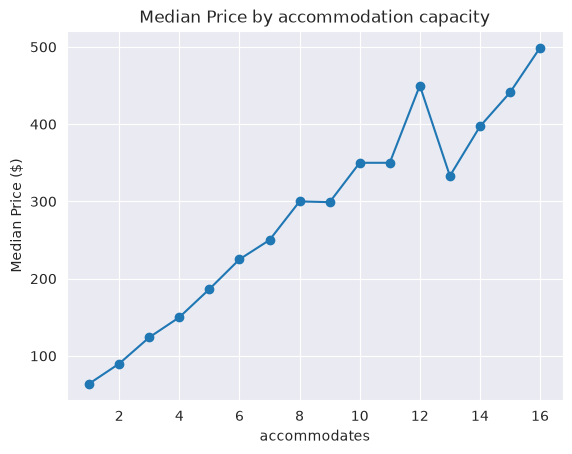

In [46]:
df.groupby('accommodates')['price'].median().plot(marker='o')
plt.title("Median Price by accommodation capacity")
plt.ylabel("Median Price ($)")
plt.show()

In [47]:
df.groupby(['bedrooms', 'room_type'])['price'].agg([
    'median', 'mean', 'count'
])

median        mean  count
bedrooms room_type                                 
0.0      Entire home/apt   125.0  146.456079   6284
         Private room       79.0  108.236659    431
1.0      Entire home/apt   140.0  165.574127  18320
         Private room       74.0   86.860585  29301
         Shared room        45.0   63.681923   2163
2.0      Entire home/apt   199.0  239.885658  10696
         Private room       95.0  131.015267    655
3.0      Entire home/apt   289.0  358.076979   4144
         Private room       75.0  131.866667    165
4.0      Entire home/apt   400.0  512.552776   1279
         Private room       65.0  169.333333     51
5.0      Entire home/apt   500.0  649.646199    342
         Private room       50.0   91.307692     13
6.0      Entire home/apt   750.0  810.504762    105
         Private room       60.0   60.000000      1
7.0      Entire home/apt   720.0  870.710526     38
8.0      Entire home/apt   700.0  916.615385     13
         Private room       30.0   30.000000      1
9.0      Entire home/apt   714.5  807.375000      8
10.0     Entire home/apt   697.5  824.000000     10

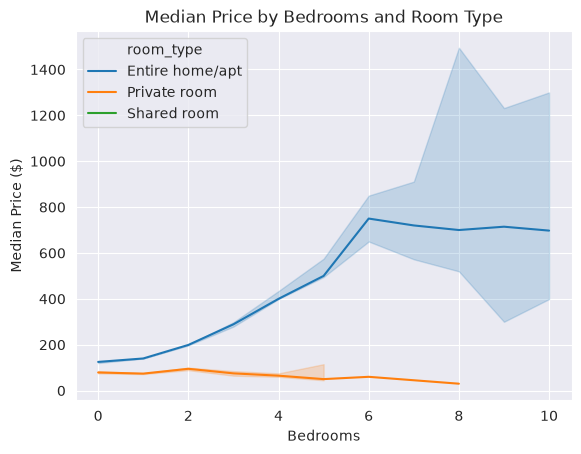

In [48]:
sns.lineplot(
    data=df,
    x='bedrooms',
    y='price',
    hue='room_type',
    estimator='median'
)

plt.title("Median Price by Bedrooms and Room Type")
plt.xlabel("Bedrooms")
plt.ylabel("Median Price ($)")
plt.show()

In [49]:
df.groupby('beds')['price'].agg([
    'median', 'mean', 'count'
])

,median,mean,count
beds,,,
0.0,247.0,250.750000,4
1.0,90.0,112.666600,45144
2.0,149.0,182.960967,16704
3.0,199.0,258.031046,6442
4.0,249.0,319.576509,3065
5.0,299.0,393.002331,1287
6.0,300.0,410.907716,661
7.0,364.0,457.805556,216
8.0,299.0,371.790323,186


In [50]:
df[df['beds'] == 0][[
    'price', 'room_type', 'bed_type', 'accommodates', 'beds', 'bedrooms'
]]

,price,room_type,bed_type,accommodates,beds,bedrooms
13672,169.0,Entire home/apt,Real Bed,2,0.0,1.0
24062,325.0,Entire home/apt,Real Bed,2,0.0,0.0
39057,109.0,Entire home/apt,Real Bed,2,0.0,0.0
55285,400.0,Entire home/apt,Real Bed,4,0.0,1.0


In [51]:
(df['beds'] > df['accommodates']).sum()

np.int64(507)

In [52]:
df[df['beds'] > df['accommodates']][[
    'price', 'accommodates', 'beds', 'bedrooms', 'bed_type', 'room_type'
]].head(20)

,price,accommodates,beds,bedrooms,bed_type,room_type
279,185.0,2,5.0,1.0,Real Bed,Private room
400,85.0,4,5.0,3.0,Real Bed,Entire home/apt
690,75.0,1,2.0,0.0,Real Bed,Private room
696,50.0,1,3.0,1.0,Real Bed,Shared room
932,150.0,1,2.0,2.0,Real Bed,Private room
1052,50.0,1,16.0,1.0,Real Bed,Shared room
1453,300.0,4,13.0,5.0,Real Bed,Private room
1519,250.0,3,4.0,3.0,Real Bed,Entire home/apt
1577,180.0,6,7.0,2.0,Real Bed,Entire home/apt
1789,300.0,1,2.0,1.0,Real Bed,Private room


In [53]:
df.groupby('bathrooms')['price'].agg([
    'median', 'mean', 'count'
])

,median,mean,count
bathrooms,,,
0.0,65.0,98.742424,198
0.5,65.0,92.344498,209
1.0,100.0,131.074941,58099
1.5,100.0,165.174428,3801
2.0,199.0,246.957283,7936
2.5,275.0,356.013401,1567
3.0,325.0,380.442777,1066
3.5,495.0,560.379953,429
4.0,450.0,508.881119,286


In [54]:
(df['bathrooms'] == 0).sum()

np.int64(198)

In [55]:
df[df['bathrooms'] == 0][[
    'price', 'room_type', 'bedrooms', 'bathrooms', 'property_type'
]].head(20)

,price,room_type,bedrooms,bathrooms,property_type
318,35.0,Private room,1.0,0.0,Apartment
1356,50.0,Shared room,1.0,0.0,Bed & Breakfast
1441,70.0,Private room,1.0,0.0,Apartment
1704,40.0,Private room,1.0,0.0,House
1819,90.0,Private room,1.0,0.0,Apartment
2034,35.0,Private room,1.0,0.0,Dorm
2068,36.0,Private room,1.0,0.0,House
2298,43.0,Private room,1.0,0.0,Condominium
2356,130.0,Private room,1.0,0.0,Apartment
2582,140.0,Entire home/apt,0.0,0.0,Apartment


In [56]:
df[df['bathrooms'] == 8].groupby('bedrooms')['price'].agg([
    'median', 'mean', 'count'
])

,median,mean,count
bedrooms,,,
0.0,70.0,70.000000,2
1.0,35.0,45.344828,29
5.0,1500.0,1500.000000,1
6.0,1700.0,1633.333333,3
7.0,1850.0,1876.666667,3
10.0,950.0,1183.333333,3


In [57]:
df[
    (df['bathrooms'] == 8) &
    (df['bedrooms'] == 1)
][
    ['price', 'accommodates', 'room_type', 'property_type', 'beds']
]

,price,accommodates,room_type,property_type,beds
6076,30.0,2,Shared room,House,2.0
8140,27.0,4,Shared room,Other,4.0
8290,54.0,1,Shared room,Dorm,1.0
8384,54.0,1,Shared room,Dorm,1.0
11109,33.0,1,Shared room,Dorm,4.0
11140,54.0,1,Shared room,Dorm,1.0
13253,100.0,2,Private room,Apartment,1.0
13370,35.0,1,Shared room,Hostel,1.0
14076,46.0,6,Shared room,Dorm,6.0
16352,44.0,4,Shared room,Hostel,1.0


In [58]:
num_cols

['accommodates',
 'bathrooms',
 'host_response_rate',
 'number_of_reviews',
 'review_scores_rating',
 'bedrooms',
 'beds']

In [59]:
df['host_response_rate'].describe()

count    55812.000000
mean        94.351967
std         16.341817
min          0.000000
25%        100.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: host_response_rate, dtype: float64

In [60]:
df['host_response_rate'].value_counts().head(20)

host_response_rate
100.0    43254
90.0      2277
80.0      1113
0.0        883
50.0       611
70.0       508
99.0       448
67.0       433
98.0       425
94.0       401
97.0       400
96.0       350
60.0       337
95.0       322
88.0       316
92.0       315
75.0       315
89.0       310
93.0       307
83.0       279
Name: count, dtype: int64

In [61]:
df['response_group'] = pd.cut(
    df['host_response_rate'],
    bins=[0, 1, 50, 80, 95, 100]
)

df.groupby('response_group')['price'] \
    .agg(['median', 'mean', 'count']) \
    .sort_index()

,median,mean,count
response_group,,,
"(1, 50]",100.0,157.044463,1192
"(50, 80]",115.0,163.363584,3482
"(80, 95]",110.0,160.914652,5378
"(95, 100]",110.0,152.820755,44877


In [62]:
df.groupby(['response_group', 'room_type'])['price'].agg([
    'median', 'mean', 'count'
])

median        mean  count
response_group room_type                                 
(1, 50]        Entire home/apt   165.0  229.505843    599
               Private room       75.0   87.199248    532
               Shared room        50.0   54.639344     61
(50, 80]       Entire home/apt   170.0  223.075162   2009
               Private room       73.0   83.769231   1352
               Shared room        42.0   61.305785    121
(80, 95]       Entire home/apt   170.0  225.345872   3004
               Private room       70.0   81.944470   2179
               Shared room        43.0   50.784615    195
(95, 100]      Entire home/apt   159.0  207.107630  25532
               Private room       71.0   83.204158  18133
               Shared room        40.0   50.762376   1212

In [63]:
df.groupby('response_group')['number_of_reviews'].agg([
    'median', 'mean', 'count'
])

,median,mean,count
response_group,,,
"(1, 50]",2.0,8.130034,1192
"(50, 80]",5.0,14.669443,3482
"(80, 95]",10.0,24.353663,5378
"(95, 100]",12.0,28.632128,44877


In [64]:
df['number_of_reviews'].describe()

count    74111.000000
mean        20.900568
std         37.828641
min          0.000000
25%          1.000000
50%          6.000000
75%         23.000000
max        605.000000
Name: number_of_reviews, dtype: float64

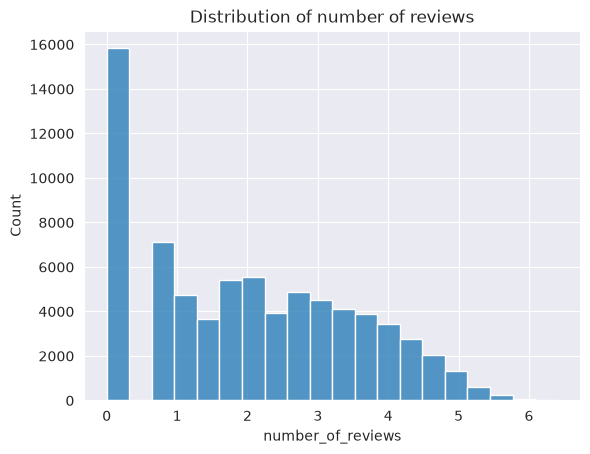

In [65]:
sns.histplot(
    x=np.log1p(df['number_of_reviews']),
    bins=20
)
plt.title("Distribution of number of reviews")
plt.show()

In [66]:
df['reviews_group'] = pd.qcut(
    df['number_of_reviews'],
    q=5,
    duplicates='drop'
)

df.groupby('reviews_group')['price'].agg([
    'median', 'mean', 'count'
])

,median,mean,count
reviews_group,,,
"(-0.001, 3.0]",115.0,179.247958,31336
"(3.0, 10.0]",110.0,150.096373,13759
"(10.0, 31.0]",115.0,150.191101,14249
"(31.0, 605.0]",110.0,139.708878,14767


In [67]:
df.groupby('reviews_group')['review_scores_rating'].median()

reviews_group
(-0.001, 3.0]    100.0
(3.0, 10.0]       96.0
(10.0, 31.0]      96.0
(31.0, 605.0]     95.0
Name: review_scores_rating, dtype: float64

In [68]:
df['review_scores_rating'].describe()

count    57389.000000
mean        94.067365
std          7.836556
min         20.000000
25%         92.000000
50%         96.000000
75%        100.000000
max        100.000000
Name: review_scores_rating, dtype: float64

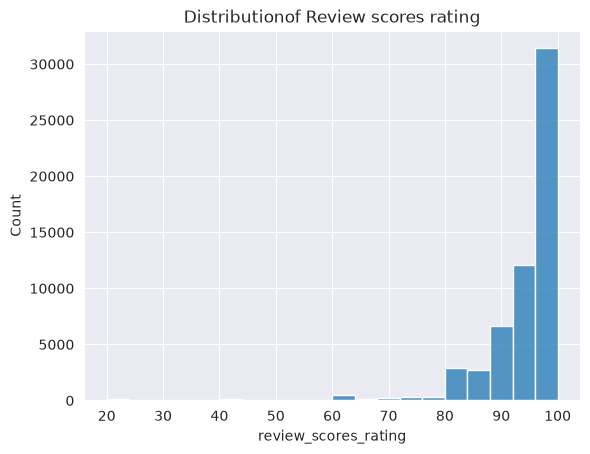

In [69]:
sns.histplot(
    df['review_scores_rating'],
    bins=20
)

plt.title("Distributionof Review scores rating")
plt.show()

In [70]:
df['review_scores_group'] = pd.cut(
    df['review_scores_rating'],
    bins=[0, 80, 90, 95, 98, 100]
)

df.groupby('review_scores_group')['price'].agg([
    'median', 'mean', 'count'
])

,median,mean,count
review_scores_group,,,
"(0, 80]",98.0,131.300361,3882
"(80, 90]",100.0,131.594540,8462
"(90, 95]",110.0,141.263894,13657
"(95, 98]",116.0,149.593207,12542
"(98, 100]",119.0,161.860713,18846


In [71]:
df.groupby('review_scores_group')['number_of_reviews'].median()

review_scores_group
(0, 80]       2.0
(80, 90]     13.0
(90, 95]     22.0
(95, 98]     25.0
(98, 100]     3.0
Name: number_of_reviews, dtype: float64

### Numerical Feature Analysis Conclusion

During the analysis of numerical features, several important relationships between numerical variables and the target variable (`price`) were identified.

The strongest relationships were observed among property-related features. Features describing the size and capacity of a listing showed a clear positive relationship with price:

* `accommodates` demonstrated a strong correlation with price. Listings with higher guest capacity generally had higher median prices, indicaating the larger proportion tend to be more expensive.
* `bedrooms` and `bathrooms` also showed a clear positive relationship with price. However, their effect on the type of accommodation. For example, listings with many bathrooms but classified as shared accommodation (such as dorms or hostels) do not necessarily represent expensive properties.
* Analysis of `beds` revealed several suspicious values, where `beds = 0`. After investigation, these cases aappeared inconsistent with other listing characteristics, as they had real beds according to `bed_type` and could accommodate guests. These values will be handled during preprocessing. A possible approach is to replace invalid zero values using information from related features, for example:
    * `if accommodates == 1`, set `beds = 1`;
    * otherwise estimate the minimum reasonable number of beds based on accommodation capacity.

----

Host-rrelated and review-related features showed weaker but still meaningful patterns:

* `host_response_rate` had a weak direct relationship with price. However it showed a strong connection with listing activity: hosts with higher response rates tended to have more reviews. This suggests that response rate may influence price indirectly through guest engagement and listing performance.
* `number_of_reviews` did not demonstrate a strong direct relationship with price. Instead it appears to represent listing activity and history rather than pricing power.
* `review_scores_rating` showed a moderate positive relationship with price. Higher-related listings generally had slighly higher prices, suggesting that guest satisfaction contributes to perceived value. However, rating values should be interpreted together with review volume, as listings with very few reviews can have artificially high scores.

----

Overal, numerical feature analysis showed that the main price drivers are structural ccharacteristics of the property, such as accommodation capacity, number of bedrooms and bathrooms. Review and host-related features appear to provide additional information, but their influence is weaker and often depends on interactions with other variables.

No additional engineered numerical features were created during this stage. The main preprocessing step identified for future implementation concerns handling inconsistent `beds` values.

## Longitude and Latitude Analysis

Unlike traditional numerical features, geographical coordinates contain spatial information that cannot be fully captured through standard statistical analysis.

The `latitude` and `longitude` features represent the physical location of each listings which may have a significant impact on the target variable (`price`).

Therefore, these features are analyzed separately to understand:

* how listings are geographicaly distributed;
* whether specific areas have different price patterns;
* whether spatial relationships can provide additional predictive power;

This section focuses not only on exploraatory analysis but also on possible feature extraction techuniques based on geographical information.

### Feature Extraction from Coordinates

Raw latitude and longitude values are often difficult for machine learning models to interpret directly.

Therefore, additional spatial features may be extracted such as:

* distance from a central reference point (`distance_from_center`);
* distance to important landmarks or city areas (if available);
* local density of listings;
* geographical clusters representing similar areas;

These features may help the model capture location-based pricing patterns more effectively.

### Spatial Clustering Experiments

Since listings located near each other often share similar characteristics, clustering algorithms can be applied to coordinate data.

Possible approaches:

* clustering listings based on `latitude` and `longitude`;
* creating categorical spatial groups;
* comparing cluster-based features with raw coordinates;

The goal is to determine whether automatically discovered geographical regions provide additional information beyond the original coordinate features.

### Comparison with Zipcode / Neighborhood Features

Geographical identifiers such as `zipcode` or `neighborhood` may contain similar information to coordinates.

Therefore, an additional experiment to compare:

* raw coordinates features;
* engineered spatial features;
* existing geographical categories;

This helps evaluate whether coordinate-based feature extrraction provides additional value or whether existing location-based features already capture most of the spatial information.

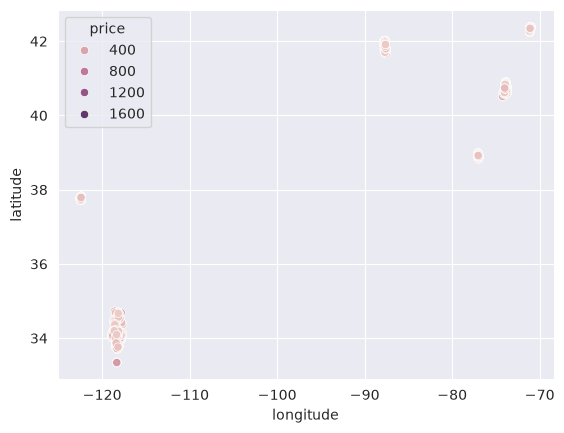

In [72]:
sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='price'
)

plt.show()

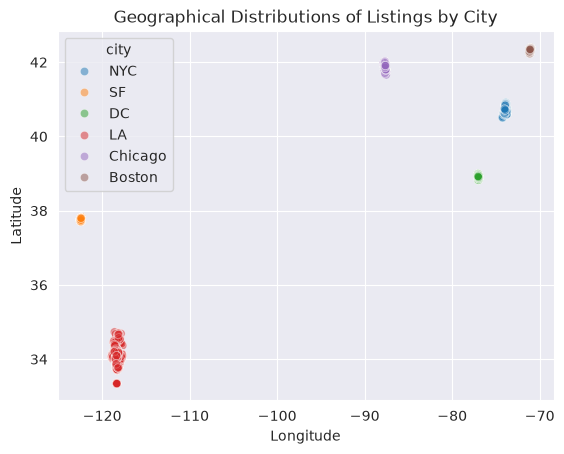

In [73]:
sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='city',
    alpha=0.5
)

plt.title("Geographical Distributions of Listings by City")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [74]:
df.groupby(
    pd.cut(df['longitude'], bins=10)
)['price'].agg(['count', 'median', 'mean'])

,count,median,mean
longitude,,,
"(-122.563, -117.359]",28887,116.0,171.421297
"(-91.596, -86.443]",3719,99.0,132.476472
"(-81.29, -76.138]",5688,125.0,217.933368
"(-76.138, -70.985]",35817,110.0,145.213502


In [75]:
df.groupby(
    pd.cut(df['latitude'], bins=10)
)['price'].agg(['count', 'median', 'mean'])

,count,median,mean
latitude,,,
"(33.33, 34.244]",22126,100.0,155.813839
"(34.244, 35.149]",327,69.0,126.590214
"(36.96, 37.865]",6434,165.0,227.372552
"(38.77, 39.675]",5688,125.0,217.933368
"(39.675, 40.58]",89,95.0,125.730337
"(40.58, 41.485]",32260,105.0,143.072288
"(41.485, 42.39]",7187,115.0,148.475024


In [76]:
df[['longitude', 'latitude']].describe()

,longitude,latitude
count,74111.000000,74111.000000
mean,-92.397525,38.445958
std,21.705322,3.080167
min,-122.511500,33.338905
25%,-118.342374,34.127908
50%,-76.996965,40.662138
75%,-73.954660,40.746096
max,-70.985047,42.390437


In [77]:
df['city'].unique()

<ArrowStringArray>
['NYC', 'SF', 'DC', 'LA', 'Chicago', 'Boston']
Length: 6, dtype: str

In [78]:
listing_centers = df.groupby('city')[['longitude', 'latitude']] \
    .median() \
    .rename(columns={
        "latitude": "listing_center_lat",
        "longitude": "listing_center_lon"
    })

listing_centers

,listing_center_lon,listing_center_lat
city,,
Boston,-71.077042,42.345295
Chicago,-87.662839,41.909945
DC,-77.022636,38.912063
LA,-118.349790,34.067141
NYC,-73.956834,40.723900
SF,-122.426735,37.768530


In [79]:
df = df.merge(listing_centers, on='city',  how='left')

df.head(2)

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds,price,host_age_days,days_since_last_review,review_history_days,host_since_year,last_review_year,first_review_year,review_before_host,response_group,reviews_group,review_scores_group,listing_center_lon,listing_center_lat
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,NYC,"Beautiful, sunlit brownstone 1-bedroom in the ...",2016-06-18,t,t,NaN,2012-03-26,f,2016-07-18,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0,150.0,2018.0,444.0,30.0,2012.0,2016.0,2016.0,0,NaN,"(-0.001, 3.0]","(98, 100]",-73.956834,40.7239
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,NYC,Enjoy travelling during your stay in Manhattan...,2017-08-05,t,f,100.0,2017-06-19,t,2017-09-23,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0,169.0,107.0,12.0,49.0,2017.0,2017.0,2017.0,0,"(95.0, 100.0]","(3.0, 10.0]","(90, 95]",-73.956834,40.7239


In [80]:
# Mean Earth radius in km
EARTH_RADIUS = 6371

lat1 = np.radians(df['latitude'])
lon1 = np.radians(df['longitude'])

lat2 = np.radians(df['listing_center_lat'])
lon2 = np.radians(df['listing_center_lon'])

def haversine(lat1, lat2, lon1, lon2):

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.asin(np.sqrt(a))

    return EARTH_RADIUS * c

df['distance_to_listing_center'] = haversine(lat1, lat2, lon1, lon2)

df['distance_to_listing_center'].describe()

count    74111.000000
mean         7.748335
std          8.215147
min          0.001732
25%          3.055308
50%          4.992963
75%          9.357726
max         83.647147
Name: distance_to_listing_center, dtype: float64

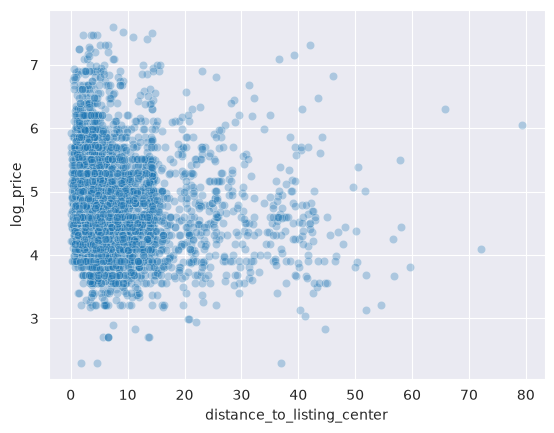

In [81]:
sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x='distance_to_listing_center',
    y='log_price',
    alpha=0.3
)

plt.show()

In [82]:
df[['distance_to_listing_center', 'log_price']].corr(method='spearman')

,distance_to_listing_center,log_price
distance_to_listing_center,1.000000,-0.222216
log_price,-0.222216,1.000000


In [83]:
df.groupby(pd.qcut(df['distance_to_listing_center'], q=10))['price'].agg([
    'median', 'mean', 'count'
])

,median,mean,count
distance_to_listing_center,,,
"(0.00073, 1.65]",145.0,190.042364,7412
"(1.65, 2.627]",135.0,181.696532,7411
"(2.627, 3.446]",135.0,188.862097,7411
"(3.446, 4.164]",125.0,178.348401,7411
"(4.164, 4.993]",119.0,165.604507,7411
"(4.993, 6.171]",105.0,146.640399,7411
"(6.171, 8.194]",99.0,138.846579,7411
"(8.194, 10.987]",95.0,126.313048,7411
"(10.987, 15.457]",99.0,141.354068,7411


In [84]:
neighbourhood_stats = (
    df.groupby('neighbourhood')['price'].agg([
        'median', 'mean', 'count'
    ]).sort_values('median')
)

neighbourhood_stats.head(10)

,median,mean,count
neighbourhood,,,
Twining,19.5,182.300000,10
South Chicago,20.0,25.000000,6
West Elsdon,30.0,30.000000,3
Daly City,32.0,223.400000,5
Grasmere,33.0,53.750000,4
West Lawn,34.0,36.250000,4
Englewood,35.0,69.384615,13
"Suitland-Silver Hill, MD",37.0,37.000000,1
Belmont Cragin,39.0,60.818182,11


In [85]:
neighbourhood_stats[neighbourhood_stats['count'] > 100].sort_values('median')

,median,mean,count
neighbourhood,,,
Elmhurst,55.0,75.465116,129
Sunset Park,59.0,74.962025,158
Jackson Heights,60.0,83.517730,141
West Adams,60.0,85.015748,127
South LA,60.0,90.768000,250
...,...,...,...
Pacific Palisades,250.0,386.265625,128
Tribeca,250.0,360.233010,103
Bel Air/Beverly Crest,259.0,527.809160,131


In [86]:
df.groupby('zipcode')[['log_price', 'distance_to_listing_center']].corr()

log_price  \
zipcode                                                                                    
                                                   log_price                    1.000000   
                                                   distance_to_listing_center   1.000000   
02108                                              log_price                    1.000000   
                                                   distance_to_listing_center  -0.151106   
02109                                              log_price                    1.000000   
...                                                                                  ...   
95202\r\r\r\r\r\r\n\r\r\r\r\r\r\n\r\r\r\r\r\r\n... distance_to_listing_center        NaN   
99135                                              log_price                         NaN   
                                                   distance_to_listing_center        NaN   
Near 91304                                         log_price                         NaN   
                                                   distance_to_listing_center        NaN   

                                                                               distance_to_listing_center  
zipcode                                                                                                    
                                                   log_price                                     1.000000  
                                                   distance_to_listing_center                    1.000000  
02108                                              log_price                                    -0.151106  
                                                   distance_to_listing_center                    1.000000  
02109                                              log_price                                    -0.325622  
...                                                                                                   ...  
95202\r\r\r\r\r\r\n\r\r\r\r\r\r\n\r\r\r\r\r\r\n... distance_to_listing_center                         NaN  
99135                                              log_price                                          NaN  
                                                   distance_to_listing_center                         NaN  
Near 91304                                         log_price                                          NaN  
                                                   distance_to_listing_center                         NaN  

[1538 rows x 2 columns]

### Longitude and Latitude Analysis Conclusion

During the analysis of geographical features, the first step was to examine the spatial distribution of listings using **latitude** and **longitude** coordinates. The scatter plot revealed several clearly separatable spatial groups, which corresponded to the existing `city` feature. This indicates that the main geographical structure of the dataset is already captured by the city labels. Therefore, applying global clustering algorithms such as **KMeans** would likely reproduce the existing city groups rather than extract additional meaningful information.

To investigate whether raw coordinates contain additional predictive information, a new feature `distance_to_listing_center` was created. The feature was calculated using the **Haversine** distance formula, implemented through a custom vectorized function, to measure the distance between each listing and estimated center of its city (using *median* values).

The analysis showed that `distance_to_listing_center` has a moderate negative relationship with `log_price`, meaning that listings located farther from the central areas tend to have lower prices. At the same time, the feature demonstrated a relationship with existing location-based feature such as `neighbourhood`, suggesting that part of its information overlaps with existing geographical features. However, it does not fully duplicate them and may capture additional spatial variation.

The relationship between `distance_to_listing_center` and `zipcode` was also investigated. However, this analysis did not provide reliable conclusions due to the high number of irregular values, repeated categories and resulting missing correlation values. The large amount of `NaN` values made correlation analysis inconclusive. This suggests that `zipcode` and `distance_to_listing_center` likely represent different aspects of geographical information rather than being direct duplicates. 

Based on the findings, `distance_to_listing_center` will be retained as a potential feature for the modeling stage. Its final contribution will be evaluated through model performance comparisons and further feature importance analysis.

## Categorical Feature Analysis

Goals for this section:

1. Examine the distribution of categorical features;
2. Identify high and low-cardinality features;
3. Anaalyze relationships between categorical features and the target variable;
4. Evaluate the predictive value of categorical features;

In [87]:
cat_features = [
    'property_type',
    'room_type',
    'bed_type',
    'cancellation_policy',
    'cleaning_fee',
    'city',
    'host_has_profile_pic',
    'host_identity_verified',
    'instant_bookable',
    'name',
    'neighbourhood',
    'thumbnail_url',
    'zipcode'
]

In [88]:
df['property_type'].nunique()

35

In [89]:
df['property_type'].value_counts()

property_type
Apartment             49003
House                 16511
Condominium            2658
Townhouse              1692
Loft                   1244
Other                   607
Guesthouse              498
Bed & Breakfast         462
Bungalow                366
Villa                   179
Dorm                    142
Guest suite             123
Camper/RV                94
Timeshare                77
Cabin                    72
In-law                   71
Hostel                   70
Boutique hotel           69
Boat                     65
Serviced apartment       21
Tent                     18
Castle                   13
Vacation home            11
Yurt                      9
Hut                       8
Treehouse                 7
Chalet                    6
Earth House               4
Tipi                      3
Train                     2
Cave                      2
Casa particular           1
Parking Space             1
Lighthouse                1
Island                    1
Name: 

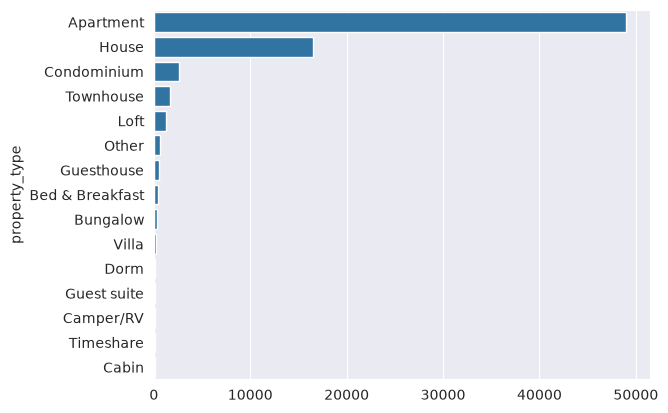

In [90]:
top = df['property_type'].value_counts().head(15)

sns.barplot(
    x=top.values,
    y=top.index
)

plt.show()

In [91]:
(df['property_type'].value_counts() < 10).sum()

np.int64(12)

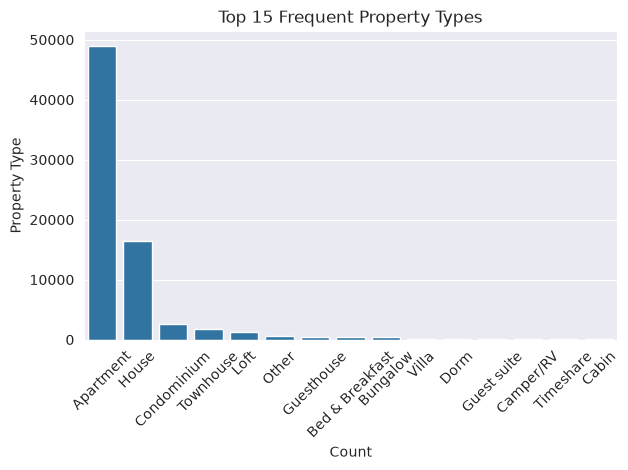

In [92]:
sns.countplot(
    data=df,
    x='property_type',
    order=top.index
)

plt.title("Top 15 Frequent Property Types")
plt.xlabel("Count")
plt.ylabel("Property Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

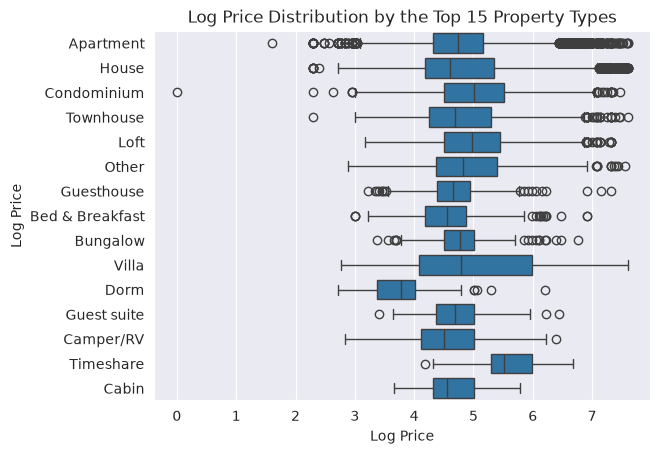

In [93]:
sns.boxplot(
    data=df[df['property_type'].isin(top.index)],
    x='log_price',
    y='property_type',
    order=top.index
)

plt.title("Log Price Distribution by the Top 15 Property Types")
plt.xlabel("Log Price")
plt.ylabel("Log Price")

plt.show()

In [94]:
summary = (
    df[df['property_type'].isin(top.index)]
    .groupby('property_type')
    .agg(
        count=('log_price', 'size'),
        median_price=('log_price', 'median'),
        mean_price=('log_price', 'mean')
    )
    .sort_values('median_price')
)

summary

,count,median_price,mean_price
property_type,,,
Dorm,142,3.783931,3.746140
Camper/RV,94,4.499810,4.602238
Bed & Breakfast,462,4.553877,4.556068
Cabin,72,4.553877,4.646499
House,16511,4.605170,4.797114
Guesthouse,498,4.653960,4.685184
Guest suite,123,4.691348,4.717513
Townhouse,1692,4.691348,4.833539
Apartment,49003,4.736198,4.758850


In [95]:
df['room_type'].value_counts(normalize=True).mul(100).round(2)

room_type
Entire home/apt    55.74
Private room       41.34
Shared room         2.92
Name: proportion, dtype: float64

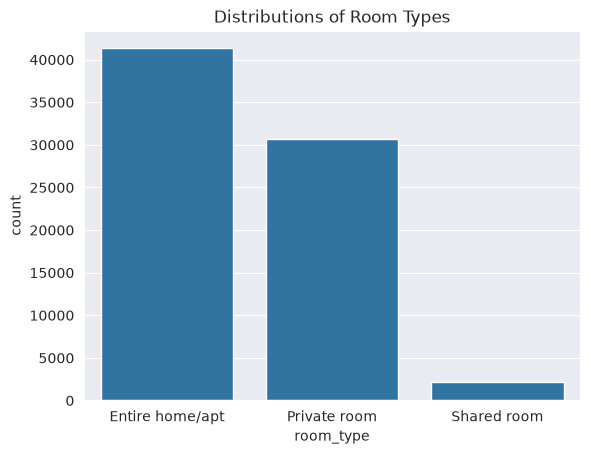

In [96]:
sns.countplot(
    data=df,
    x='room_type'
)

plt.title("Distributions of Room Types")
plt.show()

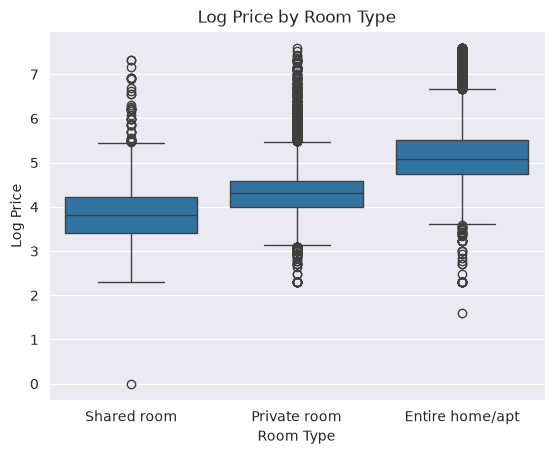

In [97]:
order = (
    df.groupby('room_type')['log_price']
        .median()
        .sort_values()
        .index
)

sns.boxplot(
    data=df,
    x='room_type',
    y='log_price',
    order=order
)

plt.title("Log Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Log Price")

plt.show()

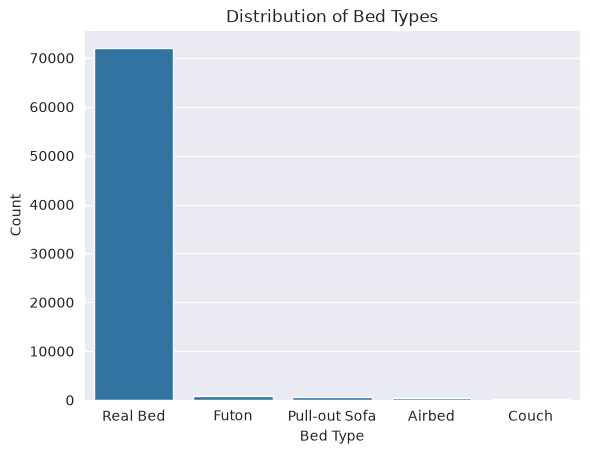

In [98]:
sns.countplot(
    data=df,
    x='bed_type',
    order=df['bed_type'].value_counts().index
)

plt.title("Distribution of Bed Types")
plt.xlabel("Bed Type")
plt.ylabel("Count")

plt.show()

In [99]:
df['bed_type'].value_counts(normalize=True).mul(100).round(2)

bed_type
Real Bed         97.19
Futon             1.02
Pull-out Sofa     0.79
Airbed            0.64
Couch             0.36
Name: proportion, dtype: float64

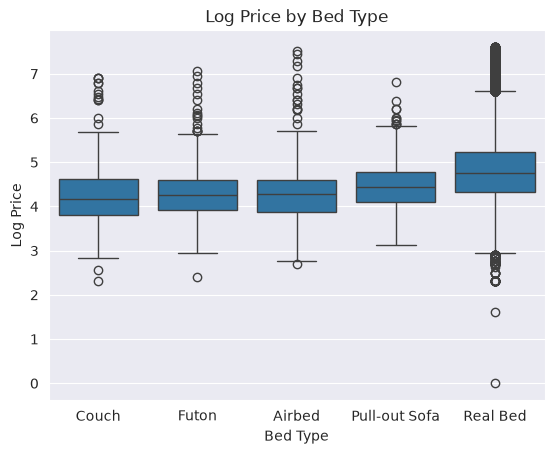

In [100]:
order = df.groupby('bed_type')['log_price'] \
    .median() \
    .sort_values() \
    .index

sns.boxplot(
    data=df,
    x='bed_type',
    y='log_price',
    order=order
)

plt.title("Log Price by Bed Type")
plt.xlabel("Bed Type"),
plt.ylabel("Log Price")

plt.show()

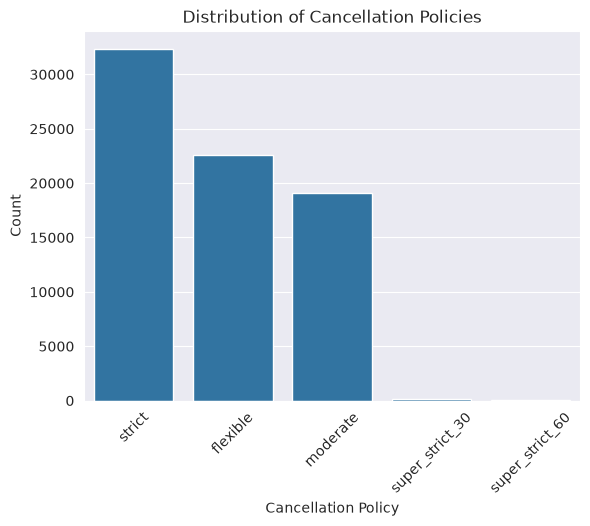

In [101]:
sns.countplot(
    data=df,
    x='cancellation_policy',
    order=df['cancellation_policy'].value_counts().index
)

plt.title("Distribution of Cancellation Policies")
plt.xlabel("Cancellation Policy")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

In [102]:
df['cancellation_policy'].value_counts(normalize=True).mul(100).round(2)

cancellation_policy
strict             43.68
flexible           30.42
moderate           25.72
super_strict_30     0.15
super_strict_60     0.02
Name: proportion, dtype: float64

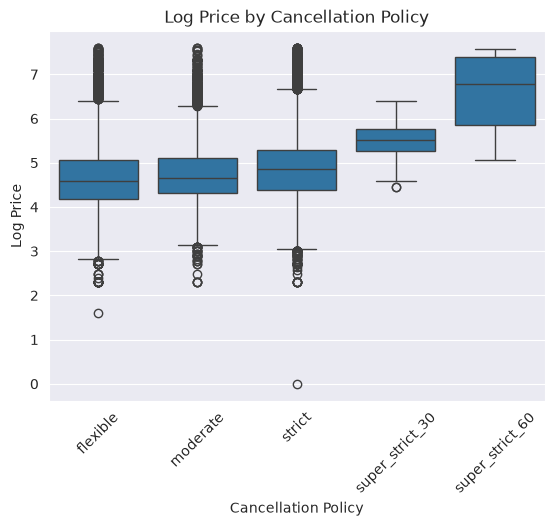

In [103]:
order = df.groupby('cancellation_policy')['log_price'] \
    .median() \
    .sort_values() \
    .index

sns.boxplot(
    data=df,
    x='cancellation_policy',
    y='log_price',
    order=order
)

plt.title("Log Price by Cancellation Policy")
plt.xlabel("Cancellation Policy")
plt.ylabel("Log Price")
plt.xticks(rotation=45)

plt.show()

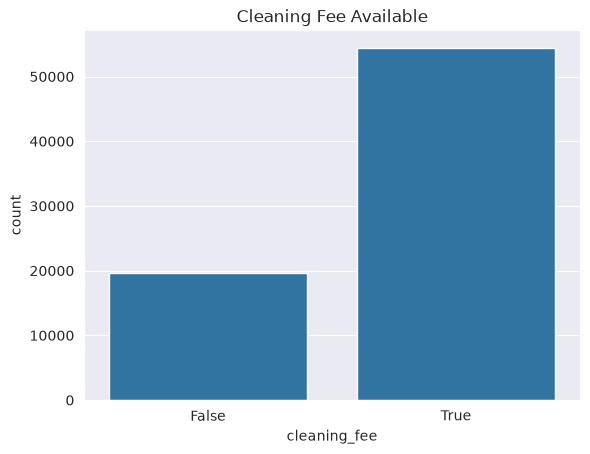

In [104]:
sns.countplot(
    data=df,
    x='cleaning_fee'
)

plt.title("Cleaning Fee Available")
plt.show()

In [105]:
df['cleaning_fee'].value_counts(normalize=True).mul(100).round(2)

cleaning_fee
True     73.41
False    26.59
Name: proportion, dtype: float64

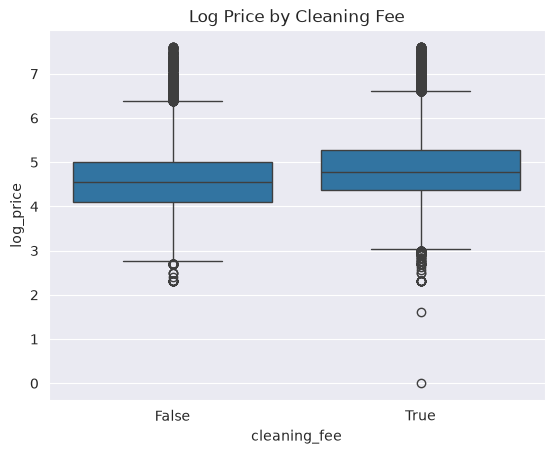

In [106]:
sns.boxplot(
    data=df,
    x='cleaning_fee',
    y='log_price'
)

plt.title("Log Price by Cleaning Fee")
plt.show()

In [107]:
df.groupby('cleaning_fee')['price'].agg([
    'count', 'mean', 'median'
])

,count,mean,median
cleaning_fee,,,
False,19708,152.380353,95.0
True,54403,163.265482,120.0


In [108]:
df['city'].nunique()

6

In [109]:
df['city'].value_counts(normalize=True).mul(100).round(2)

city
NYC        43.65
LA         30.30
SF          8.68
DC          7.67
Chicago     5.02
Boston      4.68
Name: proportion, dtype: float64

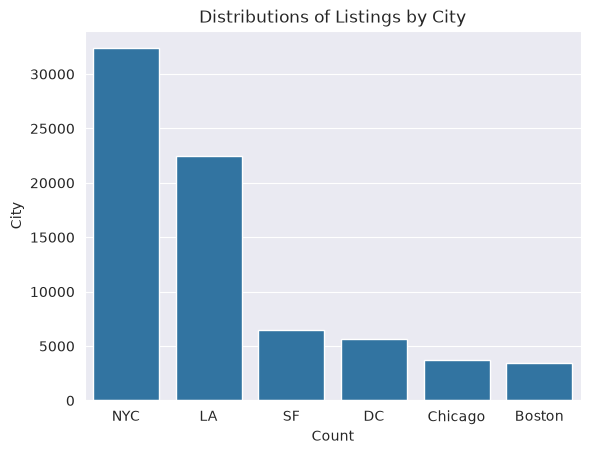

In [110]:
sns.countplot(
    data=df,
    x='city',
    order=df['city'].value_counts().index
)

plt.title("Distributions of Listings by City")
plt.xlabel("Count")
plt.ylabel("City")

plt.show()

In [111]:
city_summary = (
    df.groupby('city')['price'].agg([
        'count', 'median', 'mean'
    ]).sort_values('median')
)

city_summary

,count,median,mean
city,,,
Chicago,3719,99.0,132.476472
LA,22453,100.0,155.388233
NYC,32349,105.0,143.024576
DC,5688,125.0,217.933368
Boston,3468,136.0,165.631488
SF,6434,165.0,227.372552


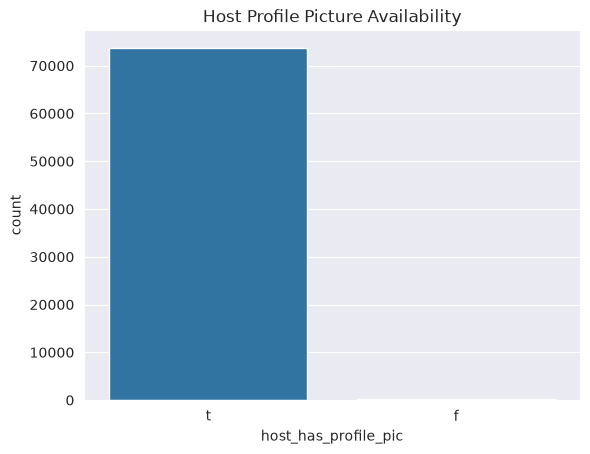

In [112]:
sns.countplot(
    data=df,
    x='host_has_profile_pic'
)

plt.title("Host Profile Picture Availability")
plt.show()

In [113]:
df['host_has_profile_pic'].value_counts(normalize=True).mul(100).round(2)

host_has_profile_pic
t    99.69
f     0.31
Name: proportion, dtype: float64

In [114]:
df.groupby('host_has_profile_pic')['price'].agg([
    'count', 'median', 'mean'
])

,count,median,mean
host_has_profile_pic,,,
f,226,132.5,206.261062
t,73697,111.0,160.279618


In [115]:
pd.crosstab(
    df['host_has_profile_pic'],
    df['host_identity_verified'],
    normalize=True
)

host_identity_verified,f,t
host_has_profile_pic,,
f,0.002949,0.000108
t,0.324080,0.672862


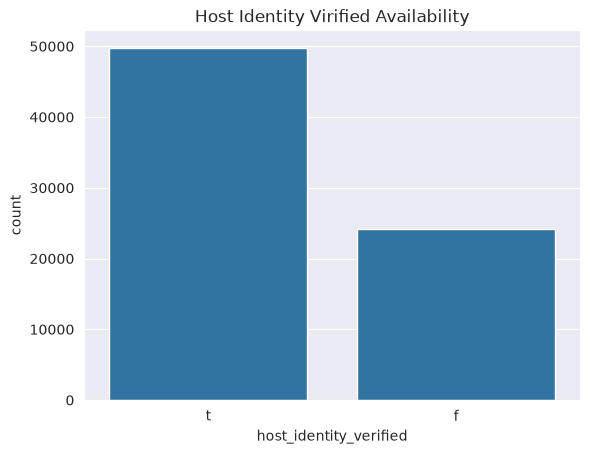

In [116]:
sns.countplot(
    data=df,
    x='host_identity_verified'
)

plt.title("Host Identity Virified Availability")
plt.show()

In [117]:
df['host_identity_verified'].value_counts(normalize=True).mul(100).round(2)

host_identity_verified
t    67.3
f    32.7
Name: proportion, dtype: float64

In [118]:
df.groupby('host_identity_verified')['price'].agg([
    'count', 'median', 'mean'
])

,count,median,mean
host_identity_verified,,,
f,24175,106.0,163.144654
t,49748,115.0,159.096245


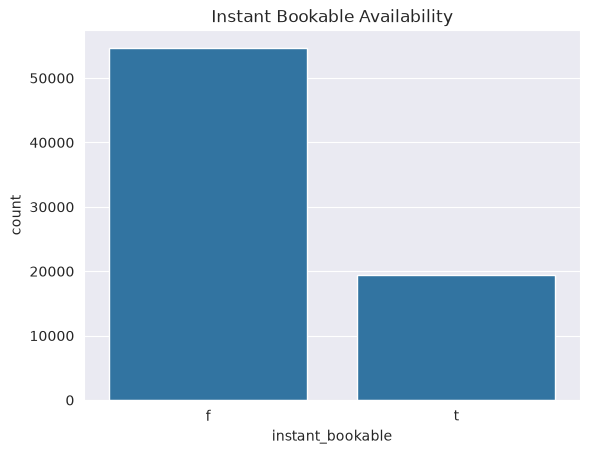

In [119]:
sns.countplot(
    data=df,
    x='instant_bookable'
)

plt.title("Instant Bookable Availability")
plt.show()

In [120]:
df['instant_bookable'].value_counts(normalize=True).mul(100).round(2)

instant_bookable
f    73.75
t    26.25
Name: proportion, dtype: float64

In [121]:
df.groupby('instant_bookable')['price'].agg([
    'count', 'median', 'mean'
])

,count,median,mean
instant_bookable,,,
f,54660,115.0,163.029235
t,19451,105.0,152.900416


In [122]:
pd.crosstab(
    df['room_type'],
    df['instant_bookable'],
    normalize='index'
)

instant_bookable,f,t
room_type,,
Entire home/apt,0.746889,0.253111
Private room,0.728703,0.271297
Shared room,0.684235,0.315765


In [123]:
df['neighbourhood'].nunique()

619

In [124]:
neigh_counts = df['neighbourhood'].value_counts()

neigh_counts.describe()

count     619.000000
mean      108.625202
std       246.429333
min         1.000000
25%         5.500000
50%        25.000000
75%       108.500000
max      2862.000000
Name: count, dtype: float64

In [125]:
top20 = neigh_counts.head(20)

top20

neighbourhood
Williamsburg          2862
Bedford-Stuyvesant    2166
Bushwick              1601
Upper West Side       1396
Mid-Wilshire          1392
Harlem                1374
Hollywood             1321
Hell's Kitchen        1299
Venice                1222
Upper East Side       1206
Crown Heights         1076
Astoria                898
Lower East Side        833
East Village           814
East Harlem            793
Mission District       784
West Hollywood         729
Chelsea                726
Greenpoint             725
Washington Heights     722
Name: count, dtype: int64

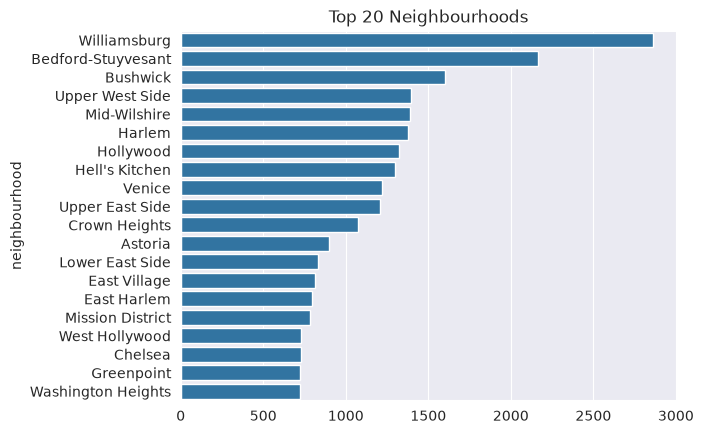

In [126]:
sns.barplot(
    x=top20.values,
    y=top20.index
)

plt.title("Top 20 Neighbourhoods")
plt.show()

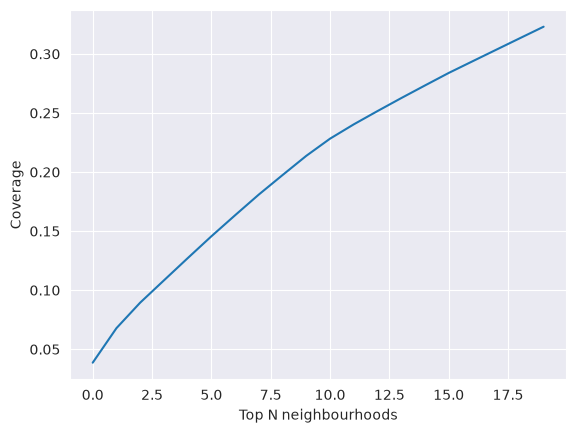

In [127]:
coverage = top20.cumsum() / len(df)

plt.plot(coverage.values)
plt.xlabel("Top N neighbourhoods")
plt.ylabel("Coverage")
plt.show()

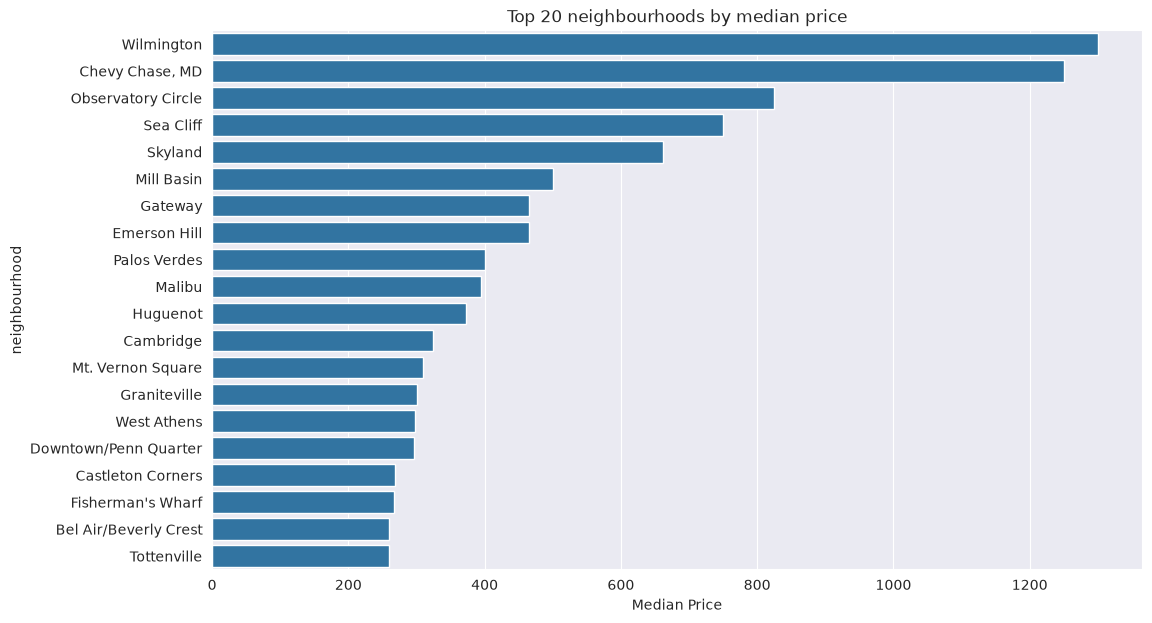

In [128]:
median_price = df.groupby('neighbourhood')['price'] \
    .median() \
    .sort_values(ascending=False) \
    .head(20)

plt.figure(figsize=(12, 7))
sns.barplot(
    x=median_price.values,
    y=median_price.index
)

plt.title("Top 20 neighbourhoods by median price")
plt.xlabel("Median Price")
plt.show()

In [129]:
df.groupby('neighbourhood')['city'].nunique().value_counts()

city
1    600
2     16
3      2
5      1
Name: count, dtype: int64

In [130]:
coverage = df['neighbourhood'].value_counts(normalize=True).cumsum()

coverage.iloc[[9, 19, 29, 49, 99]]

neighbourhood
Upper East Side       0.235563
Washington Heights    0.356028
Capitol Hill          0.442808
Sunnyside             0.553607
Redondo Beach         0.724356
Name: proportion, dtype: float64

In [131]:
n_90 = coverage.index.get_loc(coverage[coverage >= 0.9].index[0]) + 1

print(f"Number of neighbourhoods needed for 90% coverage: {n_90}")

Number of neighbourhoods needed for 90% coverage: 209


In [132]:
neighs_stats = df.groupby('neighbourhood')['price'].agg([
    'count', 'median', 'mean'
]).sort_values('median', ascending=False)

neighs_stats[neighs_stats['count'] < 20].head(20)

,count,median,mean
neighbourhood,,,
Wilmington,1,1300.0,1300.000000
"Chevy Chase, MD",1,1250.0,1250.000000
Observatory Circle,1,825.0,825.000000
Sea Cliff,5,750.0,797.000000
Skyland,2,662.5,662.500000
Mill Basin,1,500.0,500.000000
Gateway,2,465.0,465.000000
Emerson Hill,2,464.5,464.500000
Palos Verdes,7,400.0,414.285714


In [133]:
df['name'].nunique()

73359

In [134]:
df['name'].head(10)

0                       Beautiful brownstone 1-bedroom
1             Superb 3BR Apt Located Near Times Square
2                                     The Garden Oasis
3                   Beautiful Flat in the Heart of SF!
4                           Great studio in midtown DC
5                          Comfort Suite San Francisco
6                  Beach Town Studio and Parking!!!11h
7    Near LA Live, Staple's. Starbucks inside. OWN ...
8                   Cozy Garden Studio - Private Entry
9                      No.7 Queen Size Cozy Room 舒适大床房
Name: name, dtype: str

In [135]:
df['name_len'] = df['name'].str.len()

df['name_len'].describe()

count    74111.000000
mean        34.847715
std          9.420596
min          1.000000
25%         30.000000
50%         34.000000
75%         42.000000
max        179.000000
Name: name_len, dtype: float64

In [136]:
df[df['name_len'] == 1][['price', 'name']]

,price,name
18163,329.0,H
22192,178.0,p
24904,139.0,a
33453,75.0,2
47498,100.0,a
56981,75.0,3
60540,170.0,1
62581,200.0,/
70245,85.0,V


In [137]:
df[df['name_len'] <= 5][['price', 'name']]

,price,name
713,100.0,niCE
1220,70.0,M1
1461,56.0,Test
2774,55.0,Back2
2991,70.0,...
...,...,...
70245,85.0,V
71073,49.0,Ck
71084,65.0,HOME
72720,70.0,Leyla


In [138]:
df['name_len_group'] = pd.qcut(
    df['name_len'],
    q=10
)

df.groupby('name_len_group', observed=True)['price'].median()

name_len_group
(0.999, 23.0]    100.0
(23.0, 28.0]     105.0
(28.0, 31.0]     110.0
(31.0, 33.0]     115.0
(33.0, 34.0]     117.0
(34.0, 35.0]     119.0
(35.0, 39.0]     110.0
(39.0, 45.0]     115.0
(45.0, 49.0]     120.0
(49.0, 179.0]    120.0
Name: price, dtype: float64

In [139]:
df['thumbnail_url'].isna().sum()

np.int64(8216)

In [140]:
df['thumbnail_url'].isna().mean()

np.float64(0.11086073592314231)

In [141]:
df['has_thumbnail_url'] = df['thumbnail_url'].notna().astype(int)

df['has_thumbnail_url'].value_counts(normalize=True).mul(100).round(2)

has_thumbnail_url
1    88.91
0    11.09
Name: proportion, dtype: float64

In [142]:
df.groupby('has_thumbnail_url')['price'].agg([
    'count', 'median', 'mean'
])

,count,median,mean
has_thumbnail_url,,,
0,8216,149.0,218.004747
1,65895,109.0,153.184870


In [143]:
df.groupby('has_thumbnail_url')['room_type'].value_counts(normalize=True)

has_thumbnail_url  room_type      
0                  Entire home/apt    0.728092
                   Private room       0.255721
                   Shared room        0.016188
1                  Entire home/apt    0.536126
                   Private room       0.433068
                   Shared room        0.030807
Name: proportion, dtype: float64

In [144]:
df['zipcode'].nunique()

769

In [145]:
df['zipcode'].value_counts().describe()

count     769.000000
mean       95.117035
std       168.939182
min         1.000000
25%         6.000000
50%        25.000000
75%       106.000000
max      1368.000000
Name: count, dtype: float64

In [146]:
df.groupby('zipcode')['city'].nunique().value_counts()

city
1    767
2      2
Name: count, dtype: int64

In [147]:
df.groupby('city')['zipcode'].nunique()

city
Boston      40
Chicago     58
DC          40
LA         300
NYC        291
SF          42
Name: zipcode, dtype: int64

In [148]:
zip_neigh = df.groupby('zipcode')['neighbourhood'].nunique()

zip_neigh.describe()

count    769.000000
mean       2.423927
std        2.212006
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       19.000000
Name: neighbourhood, dtype: float64

In [149]:
df.groupby('neighbourhood')['zipcode'].nunique().describe()

count    619.000000
mean       3.011309
std        2.862807
min        0.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       21.000000
Name: zipcode, dtype: float64

In [150]:
df.groupby('zipcode')['price'].median()

zipcode
                                                         82.5
02108                                                   189.0
02109                                                   209.0
02110                                                   139.0
02111                                                   200.5
                                                        ...  
94158                                                   162.5
94401                                                   100.0
95202\r\r\r\r\r\r\n\r\r\r\r\r\r\n\r\r\r\r\r\r\n94158    105.0
99135                                                   340.0
Near 91304                                               89.0
Name: price, Length: 769, dtype: float64

In [151]:
bad_zip = df['zipcode'].str.contains(r"\n|\r")

bad_zip.sum()

np.int64(2)

In [152]:
df.loc[bad_zip, 'zipcode']

8264     95202\r\r\r\r\r\r\n\r\r\r\r\r\r\n\r\r\r\r\r\r\...
33426                             11249\r\r\r\r\r\r\n11249
Name: zipcode, dtype: str

In [153]:
df['zipcode'] = (
    df['zipcode'].str.replace(r"[\r\n]+", " ", regex=True)
    .str.strip()
    .str.split()
    .str[0]
)

(df['zipcode'].str.contains(r"\n|\r")).sum()

0

In [154]:
zip_freq = df['zipcode'].value_counts()

df['zipcode_freq'] = df['zipcode'].map(zip_freq)

df['zipcode_freq'].describe()

count    73143.000000
mean       394.794950
std        330.093941
min          1.000000
25%        136.000000
50%        305.000000
75%        589.000000
max       1368.000000
Name: zipcode_freq, dtype: float64

In [155]:
df['zipcode_freq_group'] = pd.qcut(
    df['zipcode_freq'],
    q=5,
    duplicates='drop'
)

df.groupby('zipcode_freq_group')['price'].median()

zipcode_freq_group
(0.999, 109.0]      88.0
(109.0, 228.0]     120.0
(228.0, 378.0]     120.0
(378.0, 632.0]     120.0
(632.0, 1368.0]    120.0
Name: price, dtype: float64

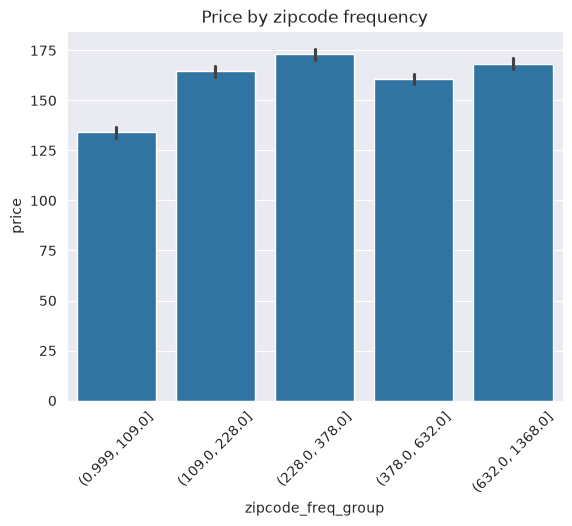

In [156]:
sns.barplot(
    data=df,
    x='zipcode_freq_group',
    y='price'
)

plt.xticks(rotation=45)
plt.title("Price by zipcode frequency")
plt.show()

### Categorical Feature Analysis Conclusion

The `property_type` feature was analyzed by examining category distribution and its relationship with price. The feature contains 35 unique categories, with several rare categories having very few observations. Since `property_type` shows a relationship with a target variable, the feature will be retained. To reduce the impact of extremely rare categories, all categories with fewer than 10 observations will be grouped into exsisting **Other** category.

The `room_type` feature contains three categories with a slight imbalance, where **Shared** room represents only a small fraction of listings. However, since the feature demonstrates predictive value through interactions with other variables and contributes useful information about listings characteristics, no preprocessing changes will be applied. The feature will be retained.

The `bed_type` feature showed a strong class imbalance, the **Real Bed** representing the vast majority of observations while other categories appeared very rarely. To reduce the impact of rare categories and simplify the representation, all *non-dominant* categories will be grouped into a single **Other** category. The transformed feature will be retained for modeling.

The `cancellation_policy` showed a strong class imbalance, with **super_strict_30** and **super_strict_60** representing only a very small fraction of observations. Although **super_strict_60** showed a higher median price compared to the regular strict caategory, the number of observaations were too small to provide reliable information and could lead to overfitting. Therefore, both **super_strict** categories will be merged with the **strict** category.

`cleaning_fee` is a balanced binary categorical feature with a moderate association with price. Listings with cleaning fees tend to have higher prices, but this feature likely reflects differences in listing type and host behavior rather than a direct casual effect.

`city` contains six balanced categories and demonstrates a strong relationship with price. Listings in *San-Francisco* and *Boston* tend to have higher prices, while *LA* and *Chicago* show lower median prices. No rare categories or annomalies were detected, so the feature can be kept without additional transformation and ecoded using **one-hot-encoding**.

`host_has_profile_pic` is a highly imbalanced feature, where almost all hosts have profile pictures. Feature provides limited additional information compared to `host_identity_verified`, and the rare `False` category is unstable due to very small number of observations. Therefore this feature will be removed during preprocessing.

`host_identity_verified` showed a slight imbalance and small correlation with price. Therefore, feature will be retained.

`instant_bookable` is a moderately imbalance binary feature. It shows a small association with price, where `instant_bookable` listings have slightly lower median prices. The feature is not strongly correlated with `room_type` and will be retained for modeling.

The `neighbourhood` feature contains a high amount of unique categories (619 neighbourhoods), while a relatively small number of neighbourhoods covers the majority of observations. Specifically, 209 neighbourhoods provide approximately 90% of data coverage, indicating that many categories are represented by only a small number of listings. Since `neighbourhood` demonstrates a strong predictive power and contains important geographical information, the feature will be retained. During preprocessing, only the most frequent neighbourhoods will be kept as separate categories, while all remaining rare neighbourhoods will be grouped into an **Other Neighbourhood** category to reduce dimensionality and avoid overfitting. 

The `name` feature a very high number of unique values, with most listings have individual names, making direct categorical encoding impractical. Additional analysis of name length showed only a weak relationship with price and rare short or unusual names did not provide meaningful predictive information. Due to high cardinally , low predictive value and the complexity of extracting reliable text-based features, the `name` feature will be removed before modeling.

The `thumbnail_url` feature was analyzed by examining the presence of thumbnail images and its relationship with target variable. Since the original feature contains **URL** values, a binary feature indicating whether a listing has thumbnail image was created for evaluation purposes. Altough the binary representation showed some difference in price, further analysis suggested that this relationship was mainly influenced by other listing characteristics, such as `room_type` rather than the presence of thumbnail itself. Therefore, the original `thumbnail_url` will be removed before modeling.

The `zipcode` feature was analyzed by examining its cardinality, relationship with existing geographical features and connection with target variable. The feature contains a high number of unique categories (769 zipcodes), indicating substanial geographical granularity. However, the feature is not fully redundant with `neighbourhood`, as both represent different levels of geographical information. The analysis showed that `zipcode` provides additional spatial granuality and should be retained for modeling. During preprocessin, the encoding strategy will depend on the selected model: categorical encoding can be used for models that handle high-cardinality features effectively, while frequency-based encoding may be considered for models where *one-hot encoding* creates excessive dimensionallity. 

## Amenities Analysis

Goals for this stage:

1. Explore the structure and content of the `amenities` feature;
2. Clean and standardize amenity values;
3. Extract meaningful features from the amenities list
4. Evalute the relationships between engineered features and the target variable;

In [157]:
df['amenities'].iloc[0]

'{"Wireless Internet","Air conditioning",Kitchen,Heating,"Family/kid friendly",Essentials,"Hair dryer",Iron,"translation missing: en.hosting_amenity_50"}'

In [158]:
df['amenities_list'] = df['amenities'].str.strip('{}') \
    .str.split(',') \
    .apply(lambda x: [item.strip().strip('"') for item in x])

type(df['amenities_list'].iloc[0])

list

In [159]:
df['amenities_list'].explode().value_counts().shape

(131,)

In [160]:
df['amenities_list'].iloc[0]

['Wireless Internet',
 'Air conditioning',
 'Kitchen',
 'Heating',
 'Family/kid friendly',
 'Essentials',
 'Hair dryer',
 'Iron',
 'translation missing: en.hosting_amenity_50']

In [161]:
df['amenities_list'].explode().str.contains("translation missing").sum()

np.int64(45718)

In [162]:
missing_amenities = df['amenities_list'].explode()

missing_amenities[missing_amenities.str.contains("translation missing")].value_counts()

amenities_list
translation missing: en.hosting_amenity_50    25291
translation missing: en.hosting_amenity_49    20427
Name: count, dtype: int64

In [163]:
df['amenities_list'].apply(
    lambda x: any("translation missing" in amenity for amenity in x)
).sum()

np.int64(27301)

In [164]:
mask = df['amenities_list'].apply(
    lambda x: len(x) > 0 and all(
        "translation missing" in amenity for amenity in x
    )
)

mask.sum()

np.int64(148)

In [165]:
df.loc[mask, ['amenities_list', 'price', 'city', 'room_type']].head(15).sort_values('price')

,amenities_list,price,city,room_type
3247,"[translation missing: en.hosting_amenity_49, t...",22.0,LA,Private room
551,[translation missing: en.hosting_amenity_49],28.0,LA,Shared room
533,"[translation missing: en.hosting_amenity_49, t...",32.0,LA,Private room
4918,"[translation missing: en.hosting_amenity_49, t...",45.0,LA,Shared room
1356,"[translation missing: en.hosting_amenity_49, t...",50.0,LA,Shared room
573,"[translation missing: en.hosting_amenity_49, t...",50.0,LA,Private room
5053,"[translation missing: en.hosting_amenity_49, t...",55.0,LA,Private room
5493,"[translation missing: en.hosting_amenity_49, t...",64.0,NYC,Private room
5336,"[translation missing: en.hosting_amenity_49, t...",100.0,NYC,Private room
1530,"[translation missing: en.hosting_amenity_49, t...",110.0,LA,Private room


In [166]:
df['amenities_list'] = df['amenities_list'].apply(
    lambda x: [amenity for amenity in x if "translation missing" not in amenity]
)

df['amenities_list'].explode().str.contains("translation missing").sum()

np.int64(0)

In [167]:
(df['amenities_list'].str.len() == 0).sum()

np.int64(148)

In [168]:
amenities_freq = df['amenities_list'].explode().value_counts()

amenities_freq

amenities_list
Wireless Internet                      71265
Kitchen                                67526
Heating                                67073
Essentials                             64005
Smoke detector                         61727
                                       ...  
Hand soap                                  1
Bath towel                                 1
Hand or paper towel                        1
Toilet paper                               1
Wide clearance to shower and toilet        1
Name: count, Length: 129, dtype: int64

In [169]:
amenities_freq[amenities_freq <= 15]

amenities_list
Firm matress                           15
Air purifier                           14
Ski in/Ski out                         13
Flat smooth pathway to front door      11
Paid parking off premises               7
Roll-in shower with chair               3
Grab-rails for shower and toilet        2
Body soap                               1
Hand soap                               1
Bath towel                              1
Hand or paper towel                     1
Toilet paper                            1
Wide clearance to shower and toilet     1
Name: count, dtype: int64

In [170]:
amenities_freq[amenities_freq.index.str.contains('mat', case=False)]

amenities_list
Firm mattress    115
Firm matress      15
Name: count, dtype: int64

In [171]:
df['amenities_list'] = df['amenities_list'].apply(
    lambda x: ["Firm mattress" if amenity == "Firm matress" else amenity for amenity in x]
)

amenities_freq = df['amenities_list'].explode().value_counts()

amenities_freq[amenities_freq.index.str.contains('mat', case=False)]

amenities_list
Firm mattress    130
Name: count, dtype: int64

In [172]:
pd.set_option("display.max_rows", 150)

amenities_freq

amenities_list
Wireless Internet                      71265
Kitchen                                67526
Heating                                67073
Essentials                             64005
Smoke detector                         61727
Air conditioning                       55210
TV                                     52458
Shampoo                                49465
Hangers                                49173
Carbon monoxide detector               47190
Internet                               44648
Laptop friendly workspace              43703
Hair dryer                             43330
Washer                                 43169
Dryer                                  42711
Iron                                   41687
Family/kid friendly                    37026
Fire extinguisher                      30724
First aid kit                          27532
Cable TV                               24253
Free parking on premises               23639
24-hour check-in                       1

In [173]:
amenities_freq[amenities_freq.index.str.contains("Smart", case=False)]

amenities_list
Smartlock     787
Smart lock    657
Name: count, dtype: int64

In [174]:
df['amenities_list'] = df['amenities_list'].apply(
    lambda x: ["Smart lock" if amenity == "Smartlock" else amenity for amenity in x]
)

In [175]:
amenities_freq[amenities_freq.index.str.contains("Elevator", case=False)]

amenities_list
Elevator                10820
Elevator in building     6417
Name: count, dtype: int64

In [176]:
df['amenities_list'] = df['amenities_list'].apply(
    lambda x: ["Elevator" if amenity == "Elevator in building" else amenity for amenity in x]
)

In [177]:
amenities_freq[amenities_freq.index.str.contains("Doorman", case=False)]

amenities_list
Doorman          4780
Doorman Entry     453
Name: count, dtype: int64

In [178]:
df['amenities_list'] = df['amenities_list'].apply(
    lambda x: ["Doorman" if amenity == "Doorman Entry" else amenity for amenity in x]
)

In [179]:
amenities_freq[amenities_freq.index.str.contains("Flat", case=False)]

amenities_list
Flat                                 397
Flat smooth pathway to front door     11
Name: count, dtype: int64

In [180]:
amenities_freq[amenities_freq.index.str.contains("smooth pathway", case=False)]

amenities_list
smooth pathway to front door         397
Flat smooth pathway to front door     11
Name: count, dtype: int64

In [181]:
df['amenities_list'] = df['amenities_list'].apply(
    lambda x: ["Flat smooth pathway to front door" if amenity == "smooth pathway to front door"
              else amenity for amenity in x if amenity != "Flat"]
)

amenities_freq = df['amenities_list'].explode().value_counts()

amenities_freq[amenities_freq.index.str.contains("Flat", case=False)]

amenities_list
Flat smooth pathway to front door    408
Name: count, dtype: int64

In [182]:
amenities_freq[amenities_freq.index.str.contains("Wide clearance to shower", case=False)]

amenities_list
Wide clearance to shower & toilet      123
Wide clearance to shower and toilet      1
Name: count, dtype: int64

In [183]:
df['amenities_list'] = df['amenities_list'].apply(
    lambda x: ["Wide clearance to shower and toilet" if amenity == "Wide clearance to shower & toilet"
              else amenity for amenity in x]
)

In [184]:
amenities_freq[amenities_freq.index == ""]

amenities_list
    586
Name: count, dtype: int64

In [185]:
df.loc[df['amenities_list'].apply(lambda x: "" in x), 'amenities_list'].head()

64     []
208    []
221    []
313    []
378    []
Name: amenities_list, dtype: object

In [186]:
df['amenities_list'] = df['amenities_list'].apply(
    lambda x: [amenity for amenity in x if amenity.strip() != ""]
)

amenities_freq = df['amenities_list'].explode().value_counts()

amenities_freq[amenities_freq.index == ""]

Series([], Name: count, dtype: int64)

In [187]:
(df['amenities_list'].str.len() == 0).sum()

np.int64(734)

In [188]:
amenities_freq[amenities_freq <= 15]

amenities_list
Air purifier                        14
Ski in/Ski out                      13
Paid parking off premises            7
Roll-in shower with chair            3
Grab-rails for shower and toilet     2
Body soap                            1
Hand soap                            1
Bath towel                           1
Hand or paper towel                  1
Toilet paper                         1
Name: count, dtype: int64

In [189]:
amenity_groups = {
    "Bathroom_supplies": {
        "Body soap",
        "Hand soap",
        "Bath towel",
        "Hand or paper towel",
        "Toilet paper"
    }
}

bathroom_items = amenity_groups['Bathroom_supplies']

df.loc[
    df['amenities_list'].apply(
        lambda x: any(item in bathroom_items for item in x)
    ),
    'amenities_list'
].iloc[0]

['TV',
 'Internet',
 'Wireless Internet',
 'Kitchen',
 'Indoor fireplace',
 'Heating',
 'Smoke detector',
 'Carbon monoxide detector',
 'First aid kit',
 'Essentials',
 'Shampoo',
 '24-hour check-in',
 'Hangers',
 'Hair dryer',
 'Iron',
 'Laptop friendly workspace',
 'Self Check-In',
 'Smart lock',
 'Private entrance',
 'Hot water',
 'Private bathroom',
 'Body soap',
 'Hand soap',
 'Bath towel',
 'Hand or paper towel',
 'Toilet paper',
 'Bed linens',
 'Extra pillows and blankets',
 'Microwave',
 'Coffee maker',
 'Refrigerator',
 'Dishwasher',
 'Dishes and silverware',
 'Cooking basics',
 'Oven',
 'Stove',
 'Patio or balcony',
 'Luggage dropoff allowed']

In [190]:
def merge_amenities(amenities):
    amenities = set(amenities)

    for new_name, old_names in amenity_groups.items():
        if amenities & old_names:
            amenities -= old_names
            amenities.add(new_name)

    return list(amenities)

df['amenities_list'] = df['amenities_list'].apply(merge_amenities)

amenities_freq = df['amenities_list'].explode().value_counts()

amenities_freq

amenities_list
Wireless Internet                      71265
Kitchen                                67526
Heating                                67073
Essentials                             64005
Smoke detector                         61727
Air conditioning                       55210
TV                                     52330
Shampoo                                49465
Hangers                                49173
Carbon monoxide detector               47190
Internet                               44648
Laptop friendly workspace              43703
Hair dryer                             43330
Washer                                 43169
Dryer                                  42711
Iron                                   41687
Family/kid friendly                    37026
Fire extinguisher                      30724
First aid kit                          27532
Cable TV                               24253
Free parking on premises               23639
24-hour check-in                       1

In [191]:
df['amenities_count'] = df['amenities_list'].str.len()

df['amenities_count'].describe()

count    74111.000000
mean        16.939496
std          6.847447
min          0.000000
25%         12.000000
50%         16.000000
75%         21.000000
max         80.000000
Name: amenities_count, dtype: float64

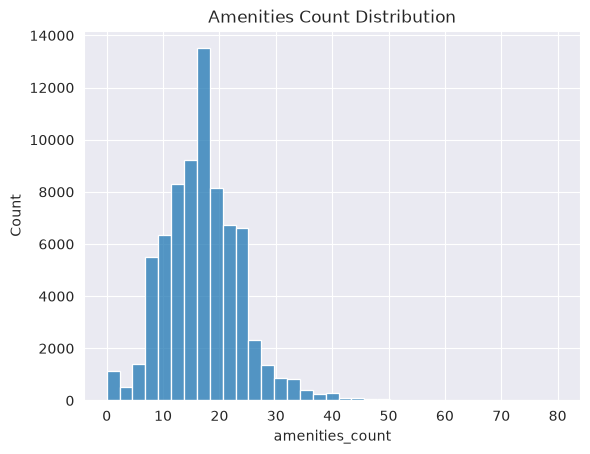

In [192]:
sns.histplot(
    df['amenities_count'],
    bins=35
)

plt.title("Amenities Count Distribution")
plt.show()

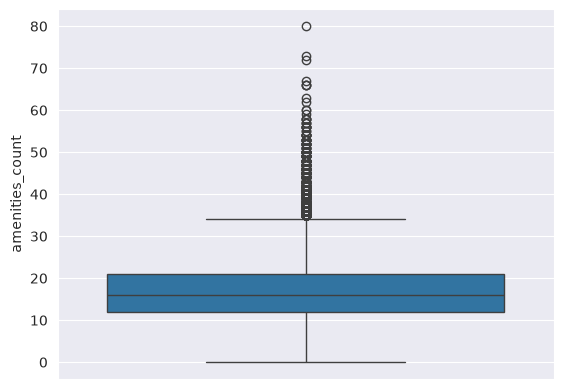

In [193]:
sns.boxplot(
    df['amenities_count']
)

plt.show()

In [194]:
df[['amenities_count', 'price']].corr(method='spearman')

,amenities_count,price
amenities_count,1.000000,0.240532
price,0.240532,1.000000


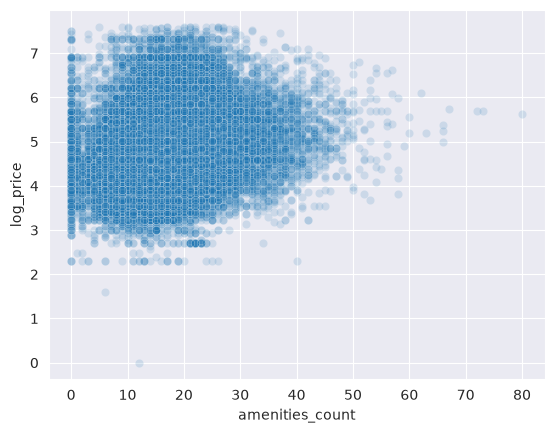

In [195]:
sns.scatterplot(
    data=df,
    x='amenities_count',
    y='log_price',
    alpha=0.15
)

plt.show()

In [196]:
df.groupby('amenities_count')['price'].agg([
    'count', 'mean', 'median'
]).head(15)

,count,mean,median
amenities_count,,,
0,734,164.713896,99.0
1,216,156.050926,99.0
2,163,127.478528,75.0
3,184,148.163043,89.0
4,326,105.711656,75.0
5,534,118.028090,79.0
6,881,111.432463,80.0
7,1321,118.665405,87.0
8,1853,122.352402,89.0


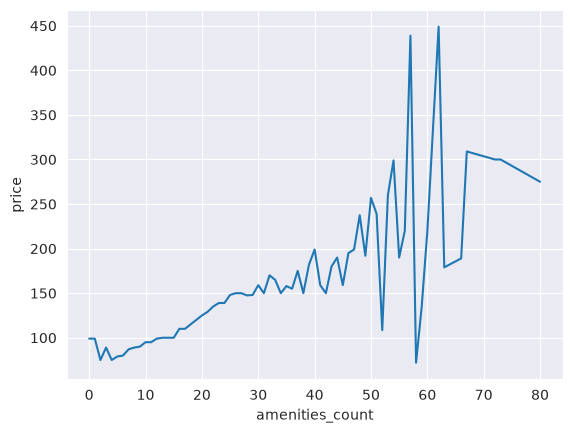

In [197]:
median_price = df.groupby('amenities_count')['price'].median()

sns.lineplot(median_price)
plt.show()

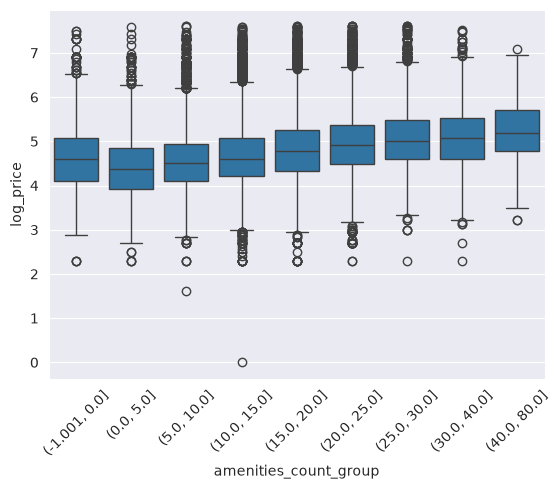

In [198]:
bins = [-1, 0, 5, 10, 15, 20, 25, 30, 40, 80]

df['amenities_count_group'] = pd.cut(
    df['amenities_count'],
    bins=bins,
    include_lowest=True
)

sns.boxplot(
    data=df,
    x='amenities_count_group',
    y='log_price'
)

plt.xticks(rotation=45)
plt.show()

In [199]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

amenities_encoded = pd.DataFrame(
    mlb.fit_transform(df['amenities_list']),
    columns=mlb.classes_,
    index=df.index
)

amenities_encoded.shape

(74111, 117)

In [200]:
amenities_encoded.head()

,24-hour check-in,Accessible-height bed,Accessible-height toilet,Air conditioning,Air purifier,BBQ grill,Baby bath,Baby monitor,Babysitter recommendations,Bathroom_supplies,Bathtub,Bathtub with shower chair,Beach essentials,Beachfront,Bed linens,Breakfast,Buzzer/wireless intercom,Cable TV,Carbon monoxide detector,Cat(s),Changing table,Children’s books and toys,Children’s dinnerware,Cleaning before checkout,Coffee maker,Cooking basics,Crib,Disabled parking spot,Dishes and silverware,Dishwasher,Dog(s),Doorman,Dryer,EV charger,Elevator,Essentials,Ethernet connection,Extra pillows and blankets,Family/kid friendly,Fire extinguisher,Fireplace guards,Firm mattress,First aid kit,Fixed grab bars for shower & toilet,Flat smooth pathway to front door,Free parking on premises,Free parking on street,Game console,Garden or backyard,Grab-rails for shower and toilet,...,Laptop friendly workspace,Lock on bedroom door,Lockbox,Long term stays allowed,Luggage dropoff allowed,Microwave,Other,Other pet(s),Outlet covers,Oven,Pack ’n Play/travel crib,Paid parking off premises,Path to entrance lit at night,Patio or balcony,Pets allowed,Pets live on this property,Pocket wifi,Pool,Private bathroom,Private entrance,Private living room,Refrigerator,Roll-in shower with chair,Room-darkening shades,Safety card,Self Check-In,Shampoo,Single level home,Ski in/Ski out,Smart lock,Smoke detector,Smoking allowed,Stair gates,Step-free access,Stove,Suitable for events,TV,Table corner guards,Washer,Washer / Dryer,Waterfront,Well-lit path to entrance,Wheelchair accessible,Wide clearance to bed,Wide clearance to shower and toilet,Wide doorway,Wide entryway,Wide hallway clearance,Window guards,Wireless Internet
0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
2,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1
4,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1


In [201]:
amenities_frequency = amenities_encoded \
    .mean() \
    .mul(100) \
    .sort_values(ascending=False) \
    .round(2)

amenities_frequency.head(20)

Wireless Internet            96.16
Kitchen                      91.11
Heating                      90.50
Essentials                   86.36
Smoke detector               83.29
Air conditioning             74.50
TV                           70.61
Shampoo                      66.74
Hangers                      66.35
Carbon monoxide detector     63.67
Internet                     60.24
Laptop friendly workspace    58.97
Hair dryer                   58.47
Washer                       58.25
Dryer                        57.63
Iron                         56.25
Family/kid friendly          49.96
Fire extinguisher            41.46
First aid kit                37.15
Cable TV                     32.73
dtype: float64

In [202]:
amenities_frequency.tail(20)

Waterfront                             0.16
Beach essentials                       0.14
Table corner guards                    0.12
Free parking on street                 0.10
Private bathroom                       0.10
Fixed grab bars for shower & toilet    0.09
EV charger                             0.07
Disabled parking spot                  0.05
Bathtub with shower chair              0.05
Beachfront                             0.04
Washer / Dryer                         0.04
Path to entrance lit at night          0.04
Ground floor access                    0.03
Lake access                            0.02
Air purifier                           0.02
Ski in/Ski out                         0.02
Paid parking off premises              0.01
Roll-in shower with chair              0.00
Grab-rails for shower and toilet       0.00
Bathroom_supplies                      0.00
dtype: float64

In [203]:
thresholds = [0.5, 1, 2, 5, 10]

for t in thresholds:
    count = (amenities_frequency >= t).sum()
    print(f">= {t}%: {count} amenities")

>= 0.5%: 82 amenities
>= 1%: 67 amenities
>= 2%: 59 amenities
>= 5%: 49 amenities
>= 10%: 32 amenities


In [204]:
selected_amenities = amenities_frequency[amenities_frequency >= 1].index

summary = []

for amenity in selected_amenities:
    summary.append({
        "Amenity": amenity,
        "Frequency (%)": amenities_encoded[amenity].mean() * 100,
        "Median Price (No)": df.loc[amenities_encoded[amenity] == 0]['price'].median(),
        "Median Price (Yes)": df.loc[amenities_encoded[amenity] == 1]['price'].median()
    })

amenities_summary = pd.DataFrame(summary)

amenities_summary['Median Difference'] = (
    amenities_summary['Median Price (Yes)'] -
    amenities_summary['Median Price (No)']
)

amenities_summary['Median Ratio (%)'] = (
    amenities_summary['Median Price (Yes)'] /
    amenities_summary['Median Price (No)'] - 1
) * 100

amenities_summary['Median Ratio (%)'] = amenities_summary['Median Ratio (%)'].round(1)

In [205]:
amenities_summary.sort_values('Frequency (%)', ascending=False).head(10)

,Amenity,Frequency (%),Median Price (No),Median Price (Yes),Median Difference,Median Ratio (%)
0,Wireless Internet,96.159814,99.0,115.0,16.0,16.2
1,Kitchen,91.114679,89.0,118.0,29.0,32.6
2,Heating,90.503434,89.0,118.0,29.0,32.6
3,Essentials,86.363698,100.0,115.0,15.0,15.0
4,Smoke detector,83.289930,100.0,115.0,15.0,15.0
5,Air conditioning,74.496364,100.0,117.0,17.0,17.0
6,TV,70.610301,85.0,128.0,43.0,50.6
7,Shampoo,66.744478,100.0,120.0,20.0,20.0
8,Hangers,66.350474,101.0,117.0,16.0,15.8
9,Carbon monoxide detector,63.674758,100.0,120.0,20.0,20.0


In [206]:
amenities_summary.sort_values('Median Difference', ascending=False).head(10)

,Amenity,Frequency (%),Median Price (No),Median Price (Yes),Median Difference,Median Ratio (%)
64,Pack ’n Play/travel crib,1.516644,110.0,175.0,65.0,59.1
63,Children’s books and toys,1.519343,110.0,170.0,60.0,54.5
38,Doorman,6.301359,109.0,160.0,51.0,46.8
55,Dishwasher,3.119645,110.0,160.0,50.0,45.5
16,Family/kid friendly,49.960195,91.0,140.0,49.0,53.8
19,Cable TV,32.725236,100.0,149.0,49.0,49.0
6,TV,70.610301,85.0,128.0,43.0,50.6
29,Indoor fireplace,12.548744,109.0,150.0,41.0,37.6
60,Patio or balcony,1.646179,110.0,150.0,40.0,36.4
40,Suitable for events,5.758929,110.0,150.0,40.0,36.4


In [207]:
amenities_summary.sort_values('Median Ratio (%)', ascending=False).head(10)

,Amenity,Frequency (%),Median Price (No),Median Price (Yes),Median Difference,Median Ratio (%)
64,Pack ’n Play/travel crib,1.516644,110.0,175.0,65.0,59.1
63,Children’s books and toys,1.519343,110.0,170.0,60.0,54.5
16,Family/kid friendly,49.960195,91.0,140.0,49.0,53.8
6,TV,70.610301,85.0,128.0,43.0,50.6
19,Cable TV,32.725236,100.0,149.0,49.0,49.0
38,Doorman,6.301359,109.0,160.0,51.0,46.8
55,Dishwasher,3.119645,110.0,160.0,50.0,45.5
29,Indoor fireplace,12.548744,109.0,150.0,41.0,37.6
31,Gym,10.107811,109.0,149.0,40.0,36.7
40,Suitable for events,5.758929,110.0,150.0,40.0,36.4


In [208]:
top15_amenities = amenities_summary[amenities_summary['Frequency (%)'] >= 5]

top15_amenities = top15_amenities.sort_values('Median Ratio (%)', ascending=False)

top15_amenities = top15_amenities.head(15)

top15_amenities

,Amenity,Frequency (%),Median Price (No),Median Price (Yes),Median Difference,Median Ratio (%)
16,Family/kid friendly,49.960195,91.0,140.0,49.0,53.8
6,TV,70.610301,85.0,128.0,43.0,50.6
19,Cable TV,32.725236,100.0,149.0,49.0,49.0
38,Doorman,6.301359,109.0,160.0,51.0,46.8
29,Indoor fireplace,12.548744,109.0,150.0,41.0,37.6
31,Gym,10.107811,109.0,149.0,40.0,36.7
40,Suitable for events,5.758929,110.0,150.0,40.0,36.4
48,Bathtub,5.074820,110.0,150.0,40.0,36.4
32,Private entrance,9.809610,109.0,145.0,36.0,33.0
1,Kitchen,91.114679,89.0,118.0,29.0,32.6


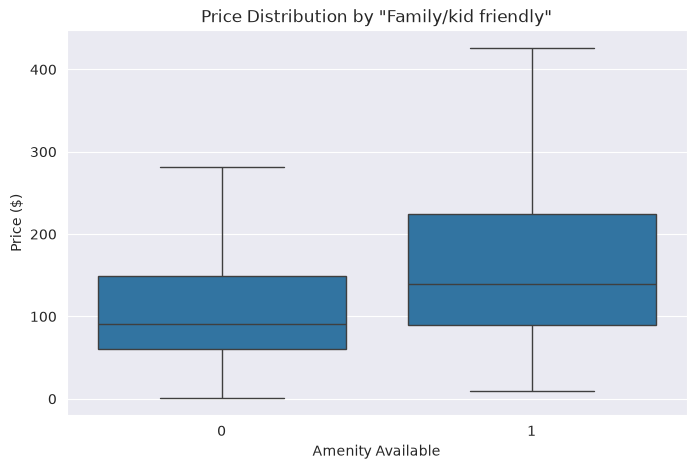

In [209]:
amenity = 'Family/kid friendly'

plot_df = df.copy()
plot_df[amenity] = amenities_encoded[amenity]

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=plot_df,
    x=amenity,
    y='price',
    showfliers=False
)

plt.title(f'Price Distribution by "{amenity}"')
plt.xlabel('Amenity Available')
plt.ylabel('Price ($)')

plt.show()

In [210]:
plot_df.groupby(amenity)['price'].agg(
    Count='count',
    Median='median',
    Mean='mean'
)

,Count,Median,Mean
Family/kid friendly,,,
0,37085,91.0,125.374275
1,37026,140.0,195.423189


In [211]:
amenities_encoded['price'] = df['price']

amenities_encoded.head()

,24-hour check-in,Accessible-height bed,Accessible-height toilet,Air conditioning,Air purifier,BBQ grill,Baby bath,Baby monitor,Babysitter recommendations,Bathroom_supplies,Bathtub,Bathtub with shower chair,Beach essentials,Beachfront,Bed linens,Breakfast,Buzzer/wireless intercom,Cable TV,Carbon monoxide detector,Cat(s),Changing table,Children’s books and toys,Children’s dinnerware,Cleaning before checkout,Coffee maker,Cooking basics,Crib,Disabled parking spot,Dishes and silverware,Dishwasher,Dog(s),Doorman,Dryer,EV charger,Elevator,Essentials,Ethernet connection,Extra pillows and blankets,Family/kid friendly,Fire extinguisher,Fireplace guards,Firm mattress,First aid kit,Fixed grab bars for shower & toilet,Flat smooth pathway to front door,Free parking on premises,Free parking on street,Game console,Garden or backyard,Grab-rails for shower and toilet,...,Lock on bedroom door,Lockbox,Long term stays allowed,Luggage dropoff allowed,Microwave,Other,Other pet(s),Outlet covers,Oven,Pack ’n Play/travel crib,Paid parking off premises,Path to entrance lit at night,Patio or balcony,Pets allowed,Pets live on this property,Pocket wifi,Pool,Private bathroom,Private entrance,Private living room,Refrigerator,Roll-in shower with chair,Room-darkening shades,Safety card,Self Check-In,Shampoo,Single level home,Ski in/Ski out,Smart lock,Smoke detector,Smoking allowed,Stair gates,Step-free access,Stove,Suitable for events,TV,Table corner guards,Washer,Washer / Dryer,Waterfront,Well-lit path to entrance,Wheelchair accessible,Wide clearance to bed,Wide clearance to shower and toilet,Wide doorway,Wide entryway,Wide hallway clearance,Window guards,Wireless Internet,price
0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,150.0
1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,169.0
2,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,145.0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,750.0
4,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,115.0


In [212]:
amenities_encoded.index.equals(df.index)

True

In [213]:
def plot_amenities_boxplots(data, amenities, ncols=3):
    n = len(amenities)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(6*ncols, 5*nrows)
    )
    axes = axes.flatten()

    for ax, amenity in zip(axes, amenities):
        sns.boxplot(
            data=data,
            x=amenity,
            y='price',
            ax=ax,
            showfliers=False
        )

        ax.set_title(amenity, fontsize=16)
        ax.set_xlabel("")
        ax.set_ylabel("Price ($)")

    for ax in axes[n:]:
        fig.delaxes(ax)

    plt.tight_layout()
    plt.show()

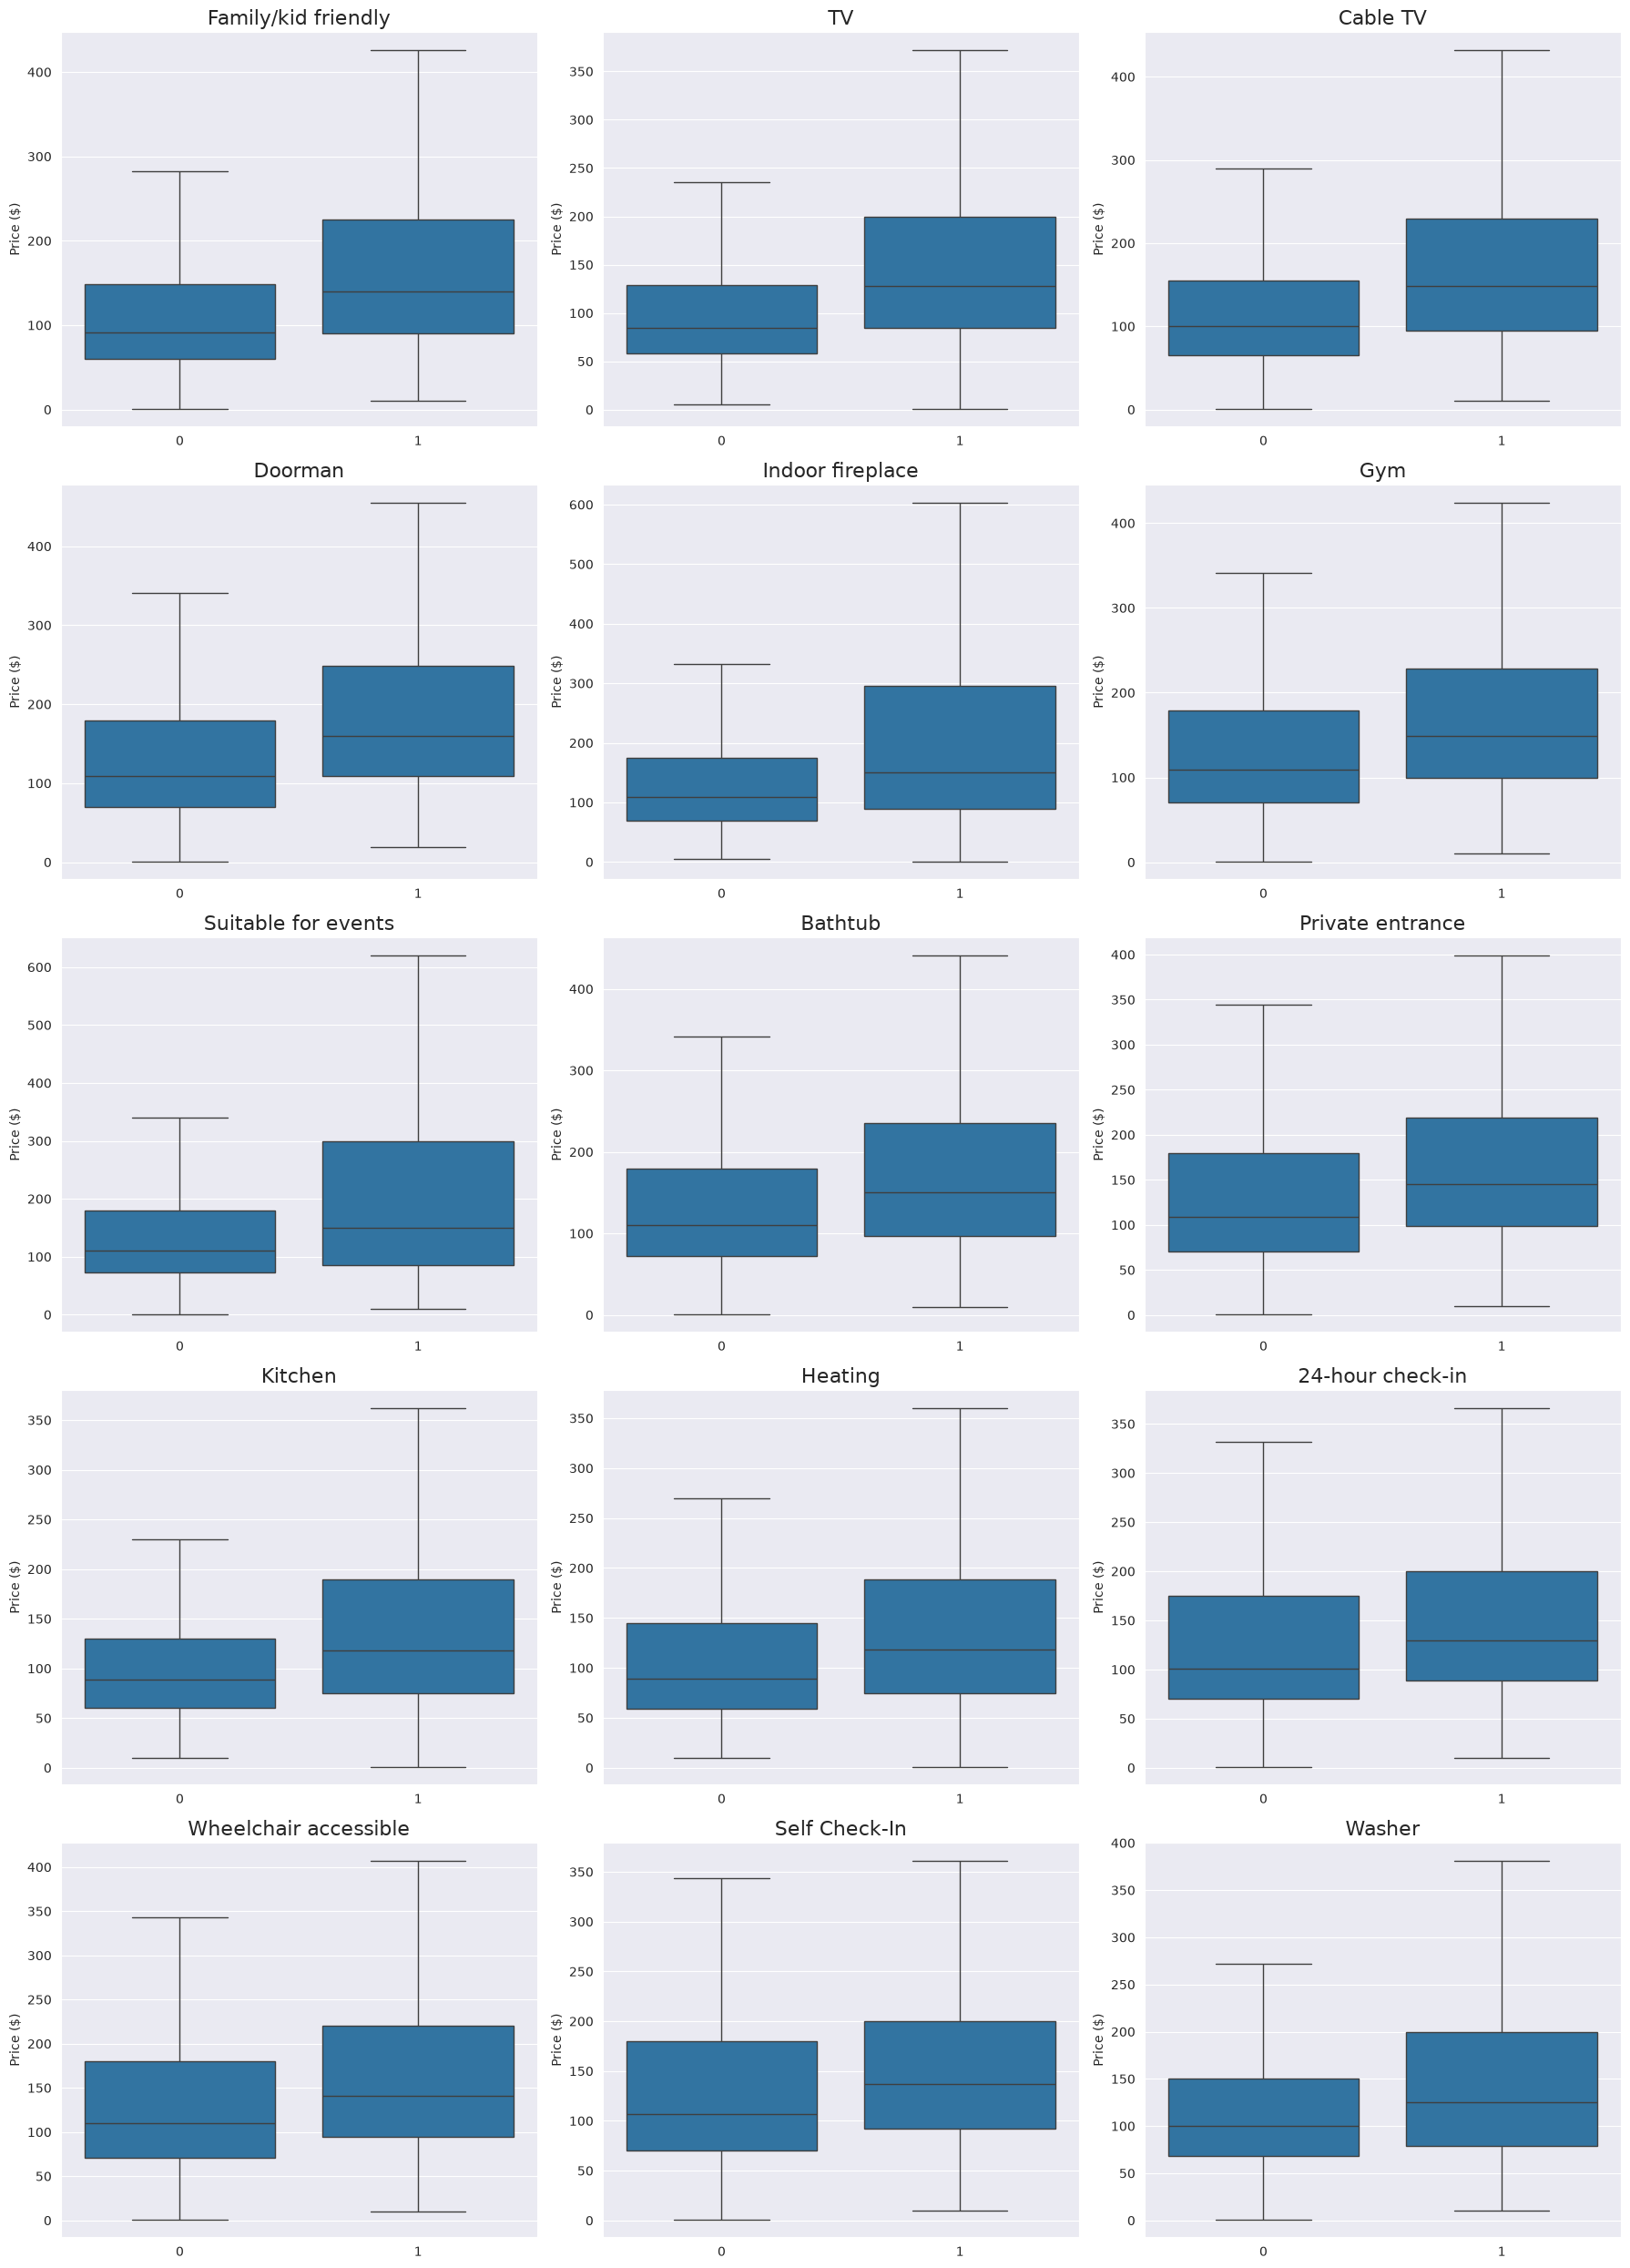

In [214]:
plot_amenities_boxplots(data=amenities_encoded, amenities=top15_amenities['Amenity'])

### Amenities Analysis Conclusion

The original `amenities` column is a raw string feature. To facilitate exploratory analysis, while preserving the original data, it was copied into a new feature named `amenities_list`, which stores amenities as *Python lists*. All subsequent preprocessing steps were performed exclusively on a list-based copy. 

Several inconsistencies and corrupted values were identified during the analysis and standardized to improve the quality of the data:

* `Firm matress` -> `Firm mattress`
* `Smartlock` -> `Smart lock`
* `Elevator in building` -> `Elevator`
* `Doorman Entry` -> `Doorman`
* `Flat`, `smooth pathway to front door` and `Flat smooth pathway to front door` were merged into a single category: `Flat smooth pathway to front door`
* `Wide clearance to shower & toilet` -> `Wide clearance to shower and toilet`

Additionally, invalid entries were removed from the amenities list:

* Empty string (`""`)
* `translation missing`

Removing these corrupted resulted in **743 listings with empty amenities lists**. These observations were intentionally retained, as the absence of listed amenities represents valid information.

To further simplify the analysis, semantically related bathroom amenities were combined into a single `bathroom_supplies` category, reducing feature redundancy while preserving their underlying meaning. This category includes:

* `Body soap`
* `Hand soap`
* `Bath towel`
* `Hand or paper towel`
* `Toilet paper`

It is important to note that these transformations were performed solely to support exploratory analysis. The same preprocessing pipeline will be reproduced during the **Feature Engineering** stage to ensure consistent data preparation.

The original `amenities` feature contained **131 unique amenities**. After removing corrupted values, correcting inconsistents and merging semantically equivalent categories, the number of unique amenities was reduced to **117**, resulting a cleaner and more consistent feature space.

To capture the the overall level of equipment offered by each listing, a new numerical feature `amenities_count` was created to represent the total number of amenities available. Corrrelation analysis showed a **weak positive relationship** with target variable (0.24). Although the relationship is relatively weak, the feature will be retained for modeling, as it still provides potential useful information about listing quality.

To enable quantitive analysis of individual amenities, the cleaned feature `amenities_list` was encoded using **MultiLabelBinarizer**, producing **117 binary features**. For convenience, these encodede features were stored in a seperate DataFrame named `amenities_encoded`, where each column indicates the precense or absence of a single amenity.

The binary amenities were subsequently analyzed using several complementary metrics, including feature frequency, median price difference and median price ratio. The analysis demonstrated that the majority of selected amenities exhibit a consistent positive association with listing price, althout the magnitude of this relationship varies across features.

For detailed exploratory analysis, the most representive amenities were selected based on their frequency and relative impact on median price. However, no binary features were removed after the analysis. All **117 encoded amenities** will be retained for the modeling stage, allowing the machine learning algorithms to determine their prredictive importance. 

## Description Analysis

Goals for this stage:

1. Explore the quality and chararteristics of listings descriptions;
2. Analyze textual properties and identify potential data quality issues;
3. Generate sentence embeddings to capture semantic information;
4. Evaluate the relationships between text-derived features and the target variable;
5. Prepare text features for downstream modeling;

### Description Analysis (Data Cleaning)

In [215]:
df['description'].dtype

<StringDtype(storage='python', na_value=<NA>)>

In [216]:
df['description_count'] = df['description'] \
    .str.strip() \
    .str.split() \
    .str.len()

df['description_count'].describe()

count    74111.000000
mean       130.423392
std         55.588904
min          1.000000
25%         81.000000
50%        160.000000
75%        173.000000
max        219.000000
Name: description_count, dtype: float64

In [217]:
(df['description_count'] == 1).sum()

np.int64(155)

In [218]:
df[df['description_count'] == 1]['description'].head(10)

364                                           靠近地铁口,走路5分钟
713                                                  GOOD
779                                                  WeHo
984                                           description
1461                                                 Test
1663    我的的房子地处在蒙罗维亚老城区市中心,步行几分钟可到图书馆、街心公园、电影院超市、美国风味餐...
2444     旅美近2年｡美西全部路线导游咨询,介绍,留学,私人订制,商务考察,房产投资,民宿长租短租等服务｡
2991                       我的房源适合情侣、孤独的冒险家、商务旅行者、家庭(带孩子)。
3528    我的房源靠近优美的景色和餐厅和餐饮。因为街区、光照、舒适的床、厨房、温馨,您一定会爱上我的房...
3735                                                    f
Name: description, dtype: string

In [219]:
chinese_mask = df['description'].str.contains(
    r"[\u4e00-\u9fff]",
    regex=True,
    na=False
)

df[chinese_mask].head()

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds,price,host_age_days,days_since_last_review,review_history_days,host_since_year,last_review_year,first_review_year,review_before_host,response_group,reviews_group,review_scores_group,listing_center_lon,listing_center_lat,distance_to_listing_center,name_len,name_len_group,has_thumbnail_url,zipcode_freq,zipcode_freq_group,amenities_list,amenities_count,amenities_count_group,description_count
9,5385260,3.583519,House,Private room,"{""Wireless Internet"",""Air conditioning"",Kitche...",2,1.0,Real Bed,moderate,True,LA,"Quiet community. Close to supermarkets,restaur...",2017-04-03,t,f,100.0,2017-03-12,t,2017-04-16,33.992563,-117.895997,No.7 Queen Size Cozy Room 舒适大床房,NaN,2,90.0,https://a0.muscache.com/im/pictures/8d2f08ce-b...,91748,1.0,1.0,36.0,206.0,172.0,13.0,2017.0,2017.0,2017.0,0,"(95, 100]","(-0.001, 3.0]","(80.0, 90.0]",-118.349790,34.067141,42.632368,31,"(28.0, 31.0]",1,258.0,"(228.0, 378.0]","[Hair dryer, Kitchen, Laptop friendly workspac...",12,"(10.0, 15.0]",121
116,8336708,4.060443,House,Private room,"{""Family/kid friendly"",""Suitable for events""}",2,1.0,Real Bed,flexible,False,LA,民宿之家 接受试住~ 提供 接送机服务~ 可包餐 也可以DIY 地理位置在罗兰岗半山富人...,2017-03-28,t,f,50.0,2017-01-09,t,2017-03-28,33.969855,-117.888092,米娜民宿 ～ 温馨 舒适～ 适合夫妻旅游或带孩子家庭,NaN,1,100.0,https://a0.muscache.com/im/pictures/15a2e63a-2...,91748,1.0,1.0,58.0,268.0,191.0,0.0,2017.0,2017.0,2017.0,0,"(1, 50]","(-0.001, 3.0]","(98.0, 100.0]",-118.349790,34.067141,43.905732,27,"(23.0, 28.0]",1,258.0,"(228.0, 378.0]","[Suitable for events, Family/kid friendly]",2,"(0.0, 5.0]",15
188,4884601,3.806662,House,Private room,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",3,0.5,Real Bed,moderate,True,LA,"Hi Travelers, This is Vicky. Welcome to LA. Ou...",2015-05-26,t,t,100.0,2015-01-11,f,2017-04-19,33.978801,-117.897380,羅蘭崗獨立屋雅房Heart of Rowland HT Cozy BR 1,NaN,63,97.0,https://a0.muscache.com/im/pictures/56b54029-9...,91748,1.0,2.0,45.0,997.0,169.0,694.0,2015.0,2017.0,2015.0,0,"(95, 100]","(31.0, 605.0]","(95.0, 98.0]",-118.349790,34.067141,42.835458,37,"(35.0, 39.0]",1,258.0,"(228.0, 378.0]","[Kitchen, Lock on bedroom door, Air conditioni...",18,"(15.0, 20.0]",157
190,11190379,4.691348,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",6,1.5,Real Bed,strict,True,LA,"位于罗兰岗中心繁华区的封闭式管理公寓小区。安全、安静,小区刷卡出入丶24小时监控管理。独立专...",2016-04-19,t,t,100.0,2016-03-15,f,2017-03-03,33.989942,-117.901666,"#A 步行两分钟到华人超市、美食街、全新装修酒店式二房二卫公寓,封闭小区",NaN,7,100.0,https://a0.muscache.com/im/pictures/d42474e4-f...,91748,2.0,2.0,109.0,568.0,216.0,318.0,2016.0,2017.0,2016.0,0,"(95, 100]","(3.0, 10.0]","(98.0, 100.0]",-118.349790,34.067141,42.179001,36,"(35.0, 39.0]",1,258.0,"(228.0, 378.0]","[Laptop friendly workspace, Dryer, Iron, Baby ...",24,"(20.0, 25.0]",58
364,142177,4.477337,House,Private room,"{""Wireless Internet"",""Air conditioning"",Kitche...",2,1.0,Real Bed,flexible,True,Boston,"靠近地铁口,走路5分钟",NaT,t,t,100.0,2015-12-28,f,NaT,42.341129,-71.143604,"Near metro station,4 mins by walk",Allston-Brighton,0,NaN,https://a0.muscache.com/im/pictures/aaebf25c-c...,02135,1.0,1.0,88.0,646.0,NaN,NaN,2015.0,NaN,NaN,0,"(95, 100]","(-0.001, 3.0]",NaN,-71.077042,42.345295,5.490104,33,"(31.0, 33.0]",1,199.0,"(109.0, 228.0]","[Laptop friendly workspace, Dryer, Iron, Carbo...",21,"(20.0, 25.0]",1


In [220]:
df.iloc[74102][['description', 'room_type', 'price']]

description    The price is for room. You will share the hous...
room_type                                            Shared room
price                                                       61.0
Name: 74102, dtype: object

In [221]:
df.iloc[74102]['description']

'The price is for room. You will share the house with my family . 我的房源适合情侣、独自旅行的冒险家、商务旅行者、有小孩的家庭、大型团体。 Single-family house located at West Hills Residential area of L.A. There are 4 private rooms with 2 bathrooms for rent, in a very nice neighbourhood. You will stay with my family and my son(1 year old) will give you a passionate welcome.  U will share the house with my (URL HIDDEN) house is in West Hills (91307). 2 people per ROOM only! keep quite and gentle!'

In [222]:
english_mask = df['description'].str.contains(
    r"[A-Za-z]",
    regex=True,
    na=False
)

pd.crosstab(chinese_mask, english_mask)

description,False,True
description,,
False,11,73152
True,149,799


In [223]:
df.loc[chinese_mask & ~english_mask, "description"].sample(20, random_state=42)

35404    房屋位于美国加州洛杉矶核桃市,房屋对面是学分为满会的核桃高中正对面,室内泳池可随时让您畅游在...
10145    华人区地理位置最好的选择,步行5分钟到达顺发、香港等多个超市,小区外有公交系统,轻松到达购物...
57503    我的房源靠近洛杉矶市中,(地理位置好,交通方便,我们提供机场名牌店景点等接送,包车游玩等服务...
37409                                      提供租车服务 !  房客有优惠
36233       我的房源靠近地铁口。因为超便宜,您一定会爱上我的房源。我的房源适合孤独的冒险家和商务旅行者。
15195                         让人充满遐想的空间,夜不能寐的时刻,一只大熊陪伴着你……
33197                                       我的房源靠近机场和公共交通。
68919    公寓位置在罗兰岗香港广场后,地理位置极佳,出门步行两分钟就是超市,附近还有很多餐馆,商场,适...
34272    整洁、凉爽的居室空间,令您放松心情。可以享受厨房自助用餐。浴室配有淋浴用品,享受拎包入住的快...
40552    我的房源靠近餐厅和餐饮和公共交通。因为光照、舒适的床、温馨,您一定会爱上我的房源。我的房源适...
54306     我的房源靠近夜生活和適合家庭的活動。我的房源適合情侶、孤獨的冒險家、商務旅行者、家庭(帶孩子)。
7644     房屋设施方面漂亮整洁,设施齐全温馨,提供餐具及炊具,电器齐全,每周有卫生员打扫卫生｡提供婴儿...
16344    含含家地理位置绝佳,出行,购物,生活非常方便,含含家干净整洁,房东是细致,爱干净的女性,会烧...
5725                            206个香蕉。加上788个葡萄  加上6809个苹果
10288    我的房源靠近餐厅和美食、适合家庭的活动、公共交通。因为温馨、地段、人,您一定会爱上我的房源。...
27393    我的房源靠近洛杉矶市中心,(地理位置好,交通方便,洛杉矶市中心,我们提供机场名牌店景点等接送...
66848                                  房间空间比较大 近各大超市生活购物

In [224]:
df.loc[chinese_mask & english_mask, 'description'].sample(10, random_state=42)

65065    The Apts location is in Rowland heights, It's ...
61560    位于peck rd 公园对面,Arcadia & El Monte 交界处。交通便利。 环境...
6485     我的房源靠近Staple Center, LA Live, Convention Cente...
50653    房源位于蒙特利公园市独立别墅,前面是花草,后院是大草坪外围一圈果树,还有凉亭和桌椅,可以看到...
6957     房间冬暖夏凉,非常适合2、3人居住,距离超市餐厅银行都很方便,只有三分钟车程,房屋对面是公园...
57296    每个卧室里的床垫是sleepy's的,非常的软,非常舒服,床上用品都是纯棉的。还配有有线频道...
33350    This stylish new building is near Kissena Park...
46728    大家好!谢谢你们的选择和支持让我被评为超赞房东,希望我的服务能为你们的美好旅程锦上添花! 二...
70010    今最もNYでオシャレスポットであるBrooklynにあります。最寄駅のLラインのMorgan...
43678    我的房子位于洛城华人区亚凯迪亚市中心,紧邻公园以及大型购物中心Santa Anita Mal...
Name: description, dtype: string

In [225]:
df.iloc[70010]['description']

'今最もNYでオシャレスポットであるBrooklynにあります。最寄駅のLラインのMorgan駅から徒歩7分ほどになります。大きなアパートの2階に私たちの部屋はあります。アパートの1階は、ショッピングモールになっていて、カフェやコンビニ、郵便局などがあります。私たちの部屋は、大きな空間の中にまた部屋が4部屋あり、そのうちの一部屋があなたのベッドルームになります。それぞれの部屋がプライバシーも守れる空間になっていますので、女性でも安心して過ごしていただけます。あなたの部屋は2階部分になるので、ハシゴを登って部屋にいくことになります。また私たちも同じ部屋の一室に住んでいるので、なにかあればいつでもお手伝いします。ベッドはクイーンサイズで、カップルでも十分なサイズだと思います。大きなリビングルームがあり、壁には以前泊まってくださったアーティストの作品が展示してあります。キッチンも共同で使っていただける調理器具や食器、調味料までご用意しております。バスルームも綺麗ですし、バーニーズニューヨークでも取り扱っているシャンプーやトリートメント、生ミネラルミストなどがご自由に使っていただけます。 リビングスペースは広々とした空間でゆったりとした時間を過ごしてほしいです。男性、女性問わず安全で清潔な空間なので、心地いいです。お部屋自体はロフトスペースになっていて、2階建になっています。あなたのお部屋はその2階部分になります。 基本的に他のゲストルームに入らない限りはどこでも大丈夫です。 私たちは出会いを大切にします。何かわからないことなどがあればいつでも行ってください。近くだったら一緒に案内しますよ! 周りは比較的静かなところで落ち着いてゆっくりしてもらえると思います。また治安もいいので女性でも安心してこれると思います。5分ほど歩くとおしゃれなカフェや古着屋さん、レストランがたくさんあるので楽しいです。また多くのギャラリーが近くにあるので、アートが好きなあなたにもオススメです! お部屋から一番近いのはLラインのMorgan駅です。だいたい徒歩5~10分です。LラインだとそのままWilliamsburgやManhattanにも行けるので楽です。 お部屋に上がるのにハシゴを登るので、それが面倒だと思われる方は、1階部分のお部屋がSBC Japanese Artist loft botto

In [226]:
df['description'].isna().sum()

np.int64(0)

In [227]:
empty_mask = df['description'].str.strip().eq('')

empty_mask.sum()

np.int64(0)

In [228]:
df['description_char_count'] = df['description'].str.strip() \
    .str.len()

df['description_char_count'].describe()

count       74111.0
mean     762.563749
std       316.95416
min             1.0
25%           482.0
50%           999.0
75%          1000.0
max          1000.0
Name: description_char_count, dtype: Float64

In [229]:
(df['description_char_count'] <= 2).sum()

np.int64(13)

In [230]:
df.loc[df['description_char_count'] <= 2, 'description']

3735      f
4100      x
9042      n
14681     .
18937    方便
19445     s
24904     a
31003     n
44971     s
47498     a
50393     .
59790     .
62581     /
Name: description, dtype: string

In [231]:
garbage = {
    "f",
    "x",
    "n",
    ".",
    "s",
    "a",
    "/"
}

In [232]:
(
    (df['description_char_count'] >= 3) &
    (df['description_char_count'] <= 5)
).sum()

np.int64(19)

In [233]:
df.loc[
    (df['description_char_count'] >= 3) & (df['description_char_count'] <= 5),
    'description'
]

713       GOOD
779       WeHo
1461      Test
11807      ...
14393     nice
17944      ...
26000      jkl
30193     nice
31512     none
32437     Cosy
36785     Dive
41774     Cool
49714    不错的地方
54054    Couch
56822    Clean
64286     民宿接待
71232     温馨如家
73175     Test
73194     Nice
Name: description, dtype: string

In [234]:
garbage.update([
    "Test",
    "...",
    "jkl",
    "none"
])

garbage

{'.', '...', '/', 'Test', 'a', 'f', 'jkl', 'n', 'none', 's', 'x'}

In [235]:
df.loc[
    df['description'].notna()
    & (df['description'].str.len() <= 10)
    & (~chinese_mask),
    'description'
].sort_values().unique()

<StringArray>
[         '.',        '...',          '/', '2 twin bed',    '2blocks',
   'BIG ROOM', 'Big studio',      'Clean',   'Clearing',       'Cool',
       'Cosy',      'Couch',  'Dasfdfads',       'Dive',  'For Carol',
       'GOOD', 'Great room', 'It's sweet', 'My camper.',       'Nice',
 'Nice Place',     'Normal', 'Not active',  'Penthouse',    'Retreat',
     'Room 6',    'SF Room',     'School', 'Sunny room',     'TEST!!',
       'Test',   'Testing.',    'Thanks!', 'The room 7',       'WeHo',
   'Westlake',    'XL Room',          'a',  'asdfsafda',  'beautiful',
    'deleted',          'f', 'good froor',        'jkl',          'n',
       'nice',       'none',    'parking',          's',     'sdsads',
 'share room',          'x']
Length: 52, dtype: string

In [236]:
garbage.update([
    "Dasfdfads",
    "TEST!!",
    "Testing",
    "Thanks!",
    "asdfsafda",
    "deleted",
    "sdsads"
])

garbage

{'.',
 '...',
 '/',
 'Dasfdfads',
 'TEST!!',
 'Test',
 'Testing',
 'Thanks!',
 'a',
 'asdfsafda',
 'deleted',
 'f',
 'jkl',
 'n',
 'none',
 's',
 'sdsads',
 'x'}

In [237]:
mask_garbage = df['description'].isin(garbage)

print(f"Garbage descriptions found: {mask_garbage.sum()}")

df.loc[mask, 'description'] = "No description"

mask = df['description'].isin(garbage)
print(f"Garbage descriptions found after cleaning: {mask.sum()}")

Garbage descriptions found: 24
Garbage descriptions found after cleaning: 24


In [238]:
html_mask = df['description'].str.contains(
    r'</?(?:p|br|div|span|strong|b|i|ul|li|ol|a|img|h[1-6])\b[^>]*>',
    regex=True,
    na=False
)

df.loc[html_mask, 'description']

Series([], Name: description, dtype: string)

In [239]:
multi_space_mask = df['description'].str.contains(r' {2,}', regex=True, na=False)

print(f'Rows with multiple spaces: {multi_space_mask.sum()}')

df.loc[multi_space_mask, 'description']

Rows with multiple spaces: 44633


1        Enjoy travelling during your stay in Manhattan...
2        The Oasis comes complete with a full backyard ...
4        Cool, cozy, and comfortable studio located in ...
6        Warm and cozy studio with full kitchen and bat...
7        Arguably the best location (and safest) in dow...
                               ...                        
74102    The price is for room. You will share the hous...
74103    CENTRALLY LOCATED Studio Unit in the WorldMark...
74104    *Location location location!!!  1B,1BA availab...
74105    Perfect for 1 person, will accept couples at a...
74108    A modern apartment located in East Williamsbur...
Name: description, Length: 44633, dtype: string

In [240]:
edge_space_mask = df['description'].str.contains(r'^\s+|\s+$', regex=True, na=False)

print(f'Rows with leading/trailing spaces: {edge_space_mask.sum()}')

df.loc[edge_space_mask, 'description']

Rows with leading/trailing spaces: 7983


10       This is a bright bedroom in an historic buildi...
11       A 1044 sq. ft., 1950's beach house. 3 Blocks f...
14       This apartment is charming and wonderful. Beau...
23       A cozy home on a beautiful tree-lined street c...
33       LOVELY ROOM Cozy, lots of light, twin/single b...
                               ...                        
74076    The apartment is much more so a *home*, than i...
74078    At this Sonder, you'll love the spacious livin...
74080    Dec. 4 - Jan. 6. 1000 sq ft loft in Bushwick, ...
74095    1 Bedroom apartment two blocks away from Subwa...
74106                            one room in bushwick apt 
Name: description, Length: 7983, dtype: string

In [241]:
punct_space_mask = df['description'].str.contains(
    r'\s+[.,!?;:]',
    regex=True,
    na=False
)

print(f'Rows with spaces before punctuation: {punct_space_mask.sum()}')

df.loc[punct_space_mask, 'description']

Rows with spaces before punctuation: 10377


12       Newly furnished room in beach apartment one st...
14       This apartment is charming and wonderful. Beau...
17       This is a nice duplex in a good location.Recen...
18       I am renting a very spacious, unique, bright L...
22       My place is close to Broken Spanish, LA Live, ...
                               ...                        
74051    Centrally located near theaters, Carnegie Hall...
74055    NEWLY RENOVATED, NEWLY FURNISHED, CLASSIC WOOD...
74089    Beautiful  two story house  nestled in peacefu...
74102    The price is for room. You will share the hous...
74110    You will stay-aboard the Island Trader at one ...
Name: description, Length: 10377, dtype: string

In [242]:
newline_mask = df['description'].str.contains(r'\n', na=False)

print(newline_mask.sum())

0


In [243]:
df['description'] = (
    df['description']
    .str.strip()
    .str.replace(r' {2,}', ' ', regex=True)
    .str.replace(r'\s+([.,!?;:])', r'\1', regex=True)
)


print(df['description'].str.contains(r' {2,}', regex=True, na=False).sum())
print(df['description'].str.contains(r'^\s+|\s+$', regex=True, na=False).sum())
print(df['description'].str.contains(r'\s+[.,!?;:]', regex=True, na=False).sum())

0
0
0


In [244]:
repeat_punct_mask = df['description'].str.contains(
    r'!{3,}|\?{3,}|\.{3,}|,{3,}|;{3,}|:{3,}',
    regex=True,
    na=False
)

print(f'Rows with repeated punctuation: {repeat_punct_mask.sum()}')

df.loc[repeat_punct_mask, 'description'].head(20)

Rows with repeated punctuation: 5481


2      The Oasis comes complete with a full backyard ...
14     This apartment is charming and wonderful. Beau...
23     A cozy home on a beautiful tree-lined street c...
33     LOVELY ROOM Cozy, lots of light, twin/single b...
34     Centrally located&very comfy, spacious one bed...
36     Beautiful, spacious, light-filled Edwardian ho...
43     Very unique and spacious apartment in the hear...
57     Trendy location - right between 2 super popula...
58     Please check for availability before you reser...
60     An Entire 2 bedroom, 600sqft, apartment w/ 4 t...
98     Visiting the City? Come stay in my cozy apt in...
145    1 bdrm avail in 2 bdrm apt. Bedroom with the h...
168    Quiet bedroom in a newly remodeled three bedro...
189    Real Luxury with a home feel! Complimentary co...
205    Beautiful spacious 450sq' en-suite, lg bthrm l...
211    FULLY REMODELED LUXURY APARTMENT STEPS FROM TH...
221    You're fashionable, not trendy... connected wi...
237    This duplex apartment is

In [245]:
df.iloc[2]['description']

"The Oasis comes complete with a full backyard with outdoor furniture to make the most of this summer vacation!! The unit has high ceilings, a completed renovation throughout, beautiful flood lighting and exposed brick! Best part, total seclusion. You share with no one! The entire unit is yours during your stay. It's a fully furnished apartment that can hold up to 5 people. The only items you need are a toothbrush and your luggage!!! The unit has high ceilings, a completed renovation throughout, beautiful flood lighting and exposed brick! Not to mention the large backyard complete with ourdoor furniture. Best part, total seclusion. You share with no one! The entire unit is yours during your stay. The entire unit and backyard Garden area My assistant is available off site via phone. Other than that, you will be alone for your stay. The neighborhood of central Harlem is very diverse and full of culture! We are a few blocks from Historic 125th Street, The Apollo Theatre, The Schomburg"

In [246]:
df['description'] = (
    df['description']
    .str.replace(r'\.{4,}', '...', regex=True)
    .str.replace(r'([!?;:,])\1{2,}', r'\1', regex=True)
)

repeat_punct_mask = df['description'].str.contains(
    r'!{3,}|\?{3,}|\.{4,}|,{3,}|;{3,}|:{3,}',
    regex=True,
    na=False
)

print(f"Rows with repeated punctuation: {repeat_punct_mask.sum()}")

Rows with repeated punctuation: 0


### Description Analysis (Data Cleaning) Conclusion

The language analysis showed that the vast majority of descriptions are written in English. Only **149 descriptions (~0.20%)** are written exclusively in Chinese, while **799 (~1.08%)** contain a mixture of both English and Chinese. This indicates that some hosts provide multilingual, which should be taken into account when generating *sentence embeddings*.

Several non-informative descriptions were identified during the exploratory analysis. These descriptions consisted of placeholder values, random character sequences, or obvious test entries. Instead of removing corresponding listings, they were replaced with "**No description**" in order to preserve the observations while assigning a consistent semantic representation for the embedding model. The following values were considered non-informative:

    garbage = {'.',
     '...',
     '/',
     'Dasfdfads',
     'TEST!!',
     'Test',
     'Testing',
     'Thanks!',
     'a',
     'asdfsafda',
     'deleted',
     'f',
     'jkl',
     'n',
     'none',
     's',
     'sdsads',
     'x'}


A total of **24** descriptions were replaced.

The dataset was also inspected for HTML tags and HTML entities. No HTML markup was found, therefore, no HTML-specific preprocessing was required.

Text formatting was inconsistent across many descriptions. Extra whitespace appeared at the beggining and end of strings, between words and before punctuation marks. To normalize whitespace while preserving original content, the following preprocessing step was applied:

    df['description'] = (
        df['description']
        .str.strip()
        .str.replace(r' {2,}', ' ', regex=True)
        .str.replace(r'\s+([.,!?;:])', r'\1', regex=True)
    )

Repeated punctuation such as multiple exclamation marks or question marks was also normalized. Ellipses were preserved by limiting long sequences of dots to exactly three characters:

    df['description'] = (
        df['description']
        .str.replace(r'\.{4,}', '...', regex=True)
        .str.replace(r'([!?;:,])\1{2,}', r'\1', regex=True)
    )

Overall the descriptions were written by thousands of different hosts, resulting in highly inconsistent writing styles, formatting, grammar and punctuation. Attempting to manually correct grammatical or spelling errors across the entire dataset would require substanial effort while providing limited practical benefit. Instead, the preprocessing focused on removing obvious noise and standardizing formatting without altering the semantic content of the descriptions.

The cleaned descriptions are now suitable for generating *Sentence Embeddings*. Since modern transformer-based embedding models are trained on real world user-generated text, they are expected to be robust to minor grammatical mistakes, informal writing styles and natural language variations. In the next stage, we will evaluate the hypothesis that *sentence embeddings* can successfully capture the semantic meaning of listing descriptions and provide useful prediction information for the final machine learning model.

### Sentence Embeddings

In [247]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("BAAI/bge-m3")

model.max_seq_length

/home/carl/notebooks/airbnb_prices_prediction/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|███████████████████████████████| 391/391 [00:00<00:00, 81688.23it/s]


8192

In [248]:
longest_description = df.loc[df['description'].str.len().idxmax(), 'description']

print(f"Characters: {len(longest_description)}")

Characters: 1000


In [249]:
tokenizer = model.tokenizer

tokens = tokenizer.encode(longest_description)

print(f"Tokens: {len(tokens)}")

Tokens: 247


In [250]:
%%time

from pathlib import Path
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

ROOT = Path.cwd().parent.resolve()
embeddings_path = ROOT / "dataset" / "description-embeddings.parquet"

if embeddings_path.exists():
    print(f"Loading embeddings from Parquet...")
    embeddings_df = pd.read_parquet(embeddings_path)

else:
    print(f"Generating Embeddings...")

    model = SentenceTransformer("BAAI/bge-m3")
    embeddings = model.encode(
        df['description'].tolist(),
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    embeddings_df = pd.DataFrame(
        embeddings,
        columns=[f"emb_{i}" for i in range(embeddings.shape[1])]
    )

    embeddings_df.to_parquet(embeddings_path, index=False)

print(embeddings_df.shape)
print(embeddings_df.dtypes)

Loading embeddings from Parquet...
(74111, 1024)
emb_0       float32
emb_1       float32
emb_2       float32
emb_3       float32
emb_4       float32
             ...   
emb_1019    float32
emb_1020    float32
emb_1021    float32
emb_1022    float32
emb_1023    float32
Length: 1024, dtype: object
CPU times: user 490 ms, sys: 465 ms, total: 955 ms
Wall time: 254 ms


In [251]:
embeddings_df.dtypes.unique()

array([dtype('float32')], dtype=object)

In [252]:
embeddings_df.isna().sum().sum()

np.int64(0)

In [253]:
norms = np.linalg.norm(
    embeddings_df.to_numpy(),
    axis=1
)

print(norms.min())
print(norms.max())
print(norms.mean())

0.999999
1.000001
1.0


In [254]:
embeddings_df.var().describe()

count    1024.000000
mean        0.000391
std         0.000094
min         0.000027
25%         0.000338
50%         0.000396
75%         0.000447
max         0.000778
dtype: float64

In [255]:
embeddings_df.iloc[:, :10].describe()

,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9
count,74111.000000,74111.000000,74111.000000,74111.000000,74111.000000,74111.000000,74111.000000,74111.000000,74111.000000,74111.000000
mean,-0.011390,0.008633,-0.058635,0.016746,-0.001119,-0.035481,-0.009011,-0.001487,0.010611,0.011055
std,0.022978,0.016749,0.016375,0.018896,0.016147,0.022893,0.020824,0.022437,0.020326,0.015937
min,-0.116203,-0.073280,-0.127524,-0.064098,-0.068105,-0.141061,-0.104026,-0.088785,-0.084657,-0.056894
25%,-0.026966,-0.002524,-0.069828,0.003916,-0.011894,-0.050747,-0.022885,-0.017010,-0.002921,0.000273
50%,-0.011599,0.008690,-0.059020,0.016913,-0.000894,-0.035395,-0.009037,-0.002259,0.010990,0.011158
75%,0.003958,0.019822,-0.047960,0.029707,0.009885,-0.020135,0.005025,0.013324,0.024631,0.021775
max,0.086224,0.081809,0.016219,0.092099,0.059301,0.064373,0.120738,0.099646,0.100326,0.078433


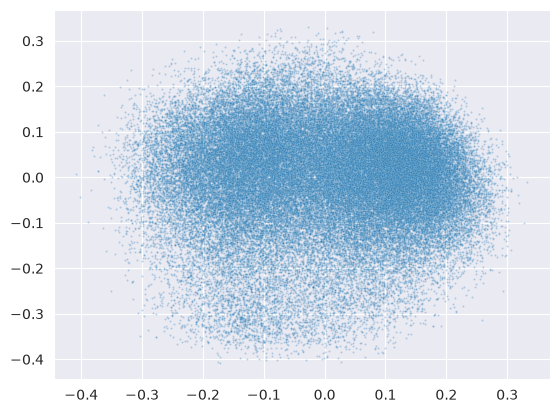

In [256]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

embeddings_2d = pca.fit_transform(embeddings_df)

sns.scatterplot(
    x=embeddings_2d[:, 0],
    y=embeddings_2d[:, 1],
    alpha=0.3,
    s=2
)

plt.show()

### Description Analysis Conclusion

The cleaned `description` feature was transformed into dense semantic embeddings using **BAAI/bge-m3** model.was Each listings was represented as **1024-dimensional** normalized embeddings vector, resulting in a dataset of shape (**74,111 x 1024**).

Several validation checks were performed after the embedding generation:

* No missing values were found;
* All embeddings features were stored as `float32`, reducing memory usage;
* No anomalies or inconsitencies were detected in the generated embedding matrix;

To avoid repeatedly generating embeddings during future experiments, the resulting dataset was saved in **Parquet** format:

    ./dataset/description-embeddings.parquet

A two-dimensional PCA projection was also created for a preliminary visual inspection of the embedding space. No obvious cluster structure was observed. However, this result should not be overinterpreted, as PCA compresses the original **1024 dimensional** semantic space into only two dimensions, inevitably discarding a substanial amount of information.

At this stage, the embedding dataset if fully prepared for the modeling phase. The usefullness of semantic embedding will be evaluated through a series of modeling hypotheses, including thier direct predictive power, dimensionality reduction techniques and potentional clustering-based feature engineering.

# Exploratory Data Analysis Conclusion

A comprehensive exploratory data analysis was conducted to investigate the dataset from multiple perspectives, including numerical, categorical, temporal, and textual features. In addition to understanding the raw data, the analysis incorporated feature engineering and feature evaluation, resulting in a well-documented set of modeling-ready features and preprocessing recommendations.